# Phase 1: Target Definition & Baseline
## Step 1.1: 신제품(NPD) 식별 및 출시 주차별 누적 매출 분포 분석

- **목표**: 각 상품의 최초 출시일을 정의하고, 출시 후 1, 2, 4주 차의 누적 매출액 분포를 통해 '성공'의 임계값($y$)을 도출합니다.
- **데이터**: `B2_POS_SALE.parquet` (전처리 완료된 POS 판매 데이터)
- **표준 컬럼명**: `판매일자`, `상품코드`, `판매금액` 등

In [41]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
import sys
from scipy.stats import spearmanr

In [18]:
# 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B4_CLEAN_FOOD_ITEM.parquet'

# 1. 데이터 로드
def load_b2(path):
    return pl.scan_parquet(path)

b2_lazy = load_b2(B2_PATH)
b4_lazy = load_b2(B4_PATH)

In [3]:
# 2. 데이터 구조 및 샘플 확인
print("\n--- B2 데이터 샘플 (상위 5개 행) ---")
display(b2_lazy.head(5).collect())


--- B2 데이터 샘플 (상위 5개 행) ---


판매일자,판매시간,점포코드,POS번호,거래번호,상품코드,판매수량,판매금액
str,str,str,str,str,str,i64,i64
"""20250523""","""084531""","""64139""","""02""","""26651""","""314952""",1,500
"""20250523""","""105724""","""52657""","""01""","""48727""","""314954""",10,45000
"""20250523""","""105724""","""52657""","""01""","""48727""","""314952""",10,5000
"""20250523""","""084531""","""64139""","""02""","""26651""","""314983""",1,4500
"""20250523""","""083823""","""50134""","""01""","""67971""","""314988""",1,4500


## Data Integrity Check (데이터 무결성 검토)

In [4]:
print("--- [검토 1] 결측치 및 데이터 다양성 점검 ---")
# pl.all().null_count().suffix("_null") 대신 .name.suffix() 사용
null_and_unique = b2_lazy.select([
    pl.all().null_count().name.suffix("_null"),
    pl.all().n_unique().name.suffix("_unique")
]).collect()
display(null_and_unique)

--- [검토 1] 결측치 및 데이터 다양성 점검 ---


판매일자_null,판매시간_null,점포코드_null,POS번호_null,거래번호_null,상품코드_null,판매수량_null,판매금액_null,판매일자_unique,판매시간_unique,점포코드_unique,POS번호_unique,거래번호_unique,상품코드_unique,판매수량_unique,판매금액_unique
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,181,86400,448,22,99999,12603,540,20395


In [5]:
print("\n--- [검토 2] 판매수량 및 판매금액 이상치 점검 (음수 매출 확인) ---")
numeric_stats = b2_lazy.select([
    pl.col("판매수량").min().alias("수량_최소"),
    pl.col("판매수량").max().alias("수량_최대"),
    (pl.col("판매수량") < 0).sum().alias("수량_0미만_건수"),
    pl.col("판매금액").min().alias("금액_최소"),
    pl.col("판매금액").max().alias("금액_최대"),
    (pl.col("판매금액") < 0).sum().alias("금액_0미만_건수")
]).collect()
display(numeric_stats)


--- [검토 2] 판매수량 및 판매금액 이상치 점검 (음수 매출 확인) ---


수량_최소,수량_최대,수량_0미만_건수,금액_최소,금액_최대,금액_0미만_건수
i64,i64,u32,i64,i64,u32
-2000,2000,1056896,-1300000000,1300000000,1030054


In [6]:
print("\n--- [검토 3] 날짜/시간 형식 점검 (길이 확인) ---")
format_check = b2_lazy.select([
    (pl.col("판매일자").str.len_chars() != 8).sum().alias("일자_형식오류_건수"),
    (pl.col("판매시간").str.len_chars() != 6).sum().alias("시간_형식오류_건수")
]).collect()
display(format_check)


--- [검토 3] 날짜/시간 형식 점검 (길이 확인) ---


일자_형식오류_건수,시간_형식오류_건수
u32,u32
0,0


In [7]:
"""
[분석 가설 및 검증 로직: 음수(-) 매출 데이터의 정체 규명]

1. 배경
   - B2 POS 데이터에서 약 103만 건의 음수(-) 판매금액 데이터가 발견됨.
   - 최대/최소 금액이 대칭(+13억, -13억)을 이루는 등 시스템적 취소 노이즈 가능성 농후.

2. 분석 가설
   - 가설 A (시스템적 즉시 취소): 점포코드, POS번호, 거래번호, 상품코드, 금액(절대값)이 동일한 양수/음수 쌍은 
     오결제 등에 의한 즉시 취소(Void) 데이터이며, 이는 실질 매출에 영향을 주지 않는 노이즈이다.
   - 가설 B (소비자 변심 반품): 양수 거래 발생 후 일정 시간(예: 수 시간~수 일) 후에 발생하는 음수 거래는 
     실제 반품이며, 신제품의 성과 측정 시 이를 상계 처리(Net)해야 한다.

3. 검증 방법론
   - 양수(+) 데이터셋과 음수(-) 데이터셋을 분리한 후, 
     ['점포코드', 'POS번호', '거래번호', '상품코드']를 키로 Inner Join을 수행하여 매칭 쌍을 탐색한다.
   - 매칭된 쌍의 '판매시간' 차이를 계산하여 즉시 취소와 사후 반품의 비중을 산출한다.
"""

def validate_negative_data(b2_lazy):
    print("--- [검증 시작] 음수 트랜잭션의 정체 및 정당성 분석 ---")

    # 1. 데이터 분리
    pos_sales = b2_lazy.filter(pl.col("판매금액") > 0)
    neg_sales = b2_lazy.filter(pl.col("판매금액") < 0)

    # 2. Key 기반 Inner Join (매칭 쌍 탐색)
    # 점포, POS, 거래번호, 상품코드가 같은 데이터 매칭
    matched_pairs = (
        neg_sales.join(
            pos_sales, 
            on=["점포코드", "POS번호", "거래번호", "상품코드"], 
            suffix="_pos"
        )
        # 금액의 절대값이 같은지 추가 확인 (부분 취소 제외, 완전 취소 타겟)
        .filter(pl.col("판매금액").abs() == pl.col("판매금액_pos"))
        .collect()
    )

    total_neg_count = neg_sales.select(pl.len()).collect().item()
    matched_count = len(matched_pairs)
    match_rate = (matched_count / total_neg_count) * 100

    print(f"전체 음수 데이터 수: {total_neg_count:,} 건")
    print(f"매칭 성공(취소 확인) 데이터 수: {matched_count:,} 건")
    print(f"매칭률(취소율): {match_rate:.2f}%")

    # 3. 시간 차이(Time Gap) 분석
    if matched_count > 0:
        # 판매시간 형식을 초 단위로 변환하여 차이 계산 (HHMMSS)
        # 시간 차이가 0 혹은 매우 짧으면 즉시 취소로 간주
        matched_pairs = matched_pairs.with_columns([
            (pl.col("판매일자") == pl.col("판매일자_pos")).alias("is_same_day")
        ])
        
        same_day_cancel_rate = (len(matched_pairs.filter(pl.col("is_same_day"))) / matched_count) * 100
        print(f"당일 취소 비중: {same_day_cancel_rate:.2f}%")

        if same_day_cancel_rate > 90:
            print("\n[결론 지지] 음수 데이터의 대부분이 당일 취소/무효화 데이터임이 입증되었습니다.")
            print("신상품의 순수 성과 분석 시 판매금액 > 0 인 데이터만 사용해도 통계적 왜곡이 미미할 것으로 판단됩니다.")
        else:
            print("\n[경고] 사후 반품 비중이 높습니다. 단순 제거 대신 기간별 상계 처리(Net Sales)가 권장됩니다.")

    return matched_pairs

In [8]:
validation_results = validate_negative_data(b2_lazy)

--- [검증 시작] 음수 트랜잭션의 정체 및 정당성 분석 ---
전체 음수 데이터 수: 1,030,054 건
매칭 성공(취소 확인) 데이터 수: 585,155 건
매칭률(취소율): 56.81%
당일 취소 비중: 99.63%

[결론 지지] 음수 데이터의 대부분이 당일 취소/무효화 데이터임이 입증되었습니다.
신상품의 순수 성과 분석 시 판매금액 > 0 인 데이터만 사용해도 통계적 왜곡이 미미할 것으로 판단됩니다.


In [9]:
"""
[2차 심층 검증: 매칭되지 않은 음수 데이터(43%)의 영향도 분석]

1. 배경
   - 1차 검증 결과, 음수 데이터의 56.8%만 즉시 취소(Void)로 확인됨.
   - 남은 43.2%가 실제 반품일 경우, 이를 제외하고 분석하는 것이 성공 지표($y$)를 왜곡할 수 있음.

2. 분석 가설
   - 가설 C (거래번호 변경 반품): 매칭되지 않은 데이터 중 상당수는 거래번호가 변경된 채 
     [점포, 상품, 금액]이 일치하는 데이터일 것이다.
   - 가설 D (순위 보존 법칙): 음수 데이터를 포함한 '순매출(Net)'과 양수만 집계한 '총매출(Gross)' 간의 
     상품별 성공 순위(Ranking)는 극도로 유사할 것이다. (상관계수 0.99 이상 예상)

3. 검증 방법론
   - [방법 1] 거래번호를 제외한 유연한 매칭(점포+상품+금액)으로 매칭률 재산출.
   - [방법 2] 상품별로 (양수+음수) 합산 매출과 (양수) 매출을 각각 계산하여 스피어만 상관계수 측정.
"""

def deep_dive_negative_data(b2_lazy):
    print("--- [2차 심층 검증] 음수 데이터 영향도 및 순위 상관관계 분석 ---")
    
    # 데이터 수집 (메모리 효율을 위해 필요한 컬럼만)
    df = b2_lazy.select(["상품코드", "판매금액"]).collect()
    
    # 1. 상품별 Gross Sales (양수만) vs Net Sales (양수+음수) 계산
    prod_stats = df.group_by("상품코드").agg([
        pl.col("판매금액").filter(pl.col("판매금액") > 0).sum().alias("gross_sales"),
        pl.col("판매금액").sum().alias("net_sales")
    ])
    
    # 2. 스피어만 상관계수(Ranking Correlation) 계산
    # 성공 지표는 결국 '누가 더 많이 팔렸나'의 순위가 중요함
    gross_vals = prod_stats["gross_sales"].to_numpy()
    net_vals = prod_stats["net_sales"].to_numpy()
    
    corr, _ = spearmanr(gross_vals, net_vals)
    
    print(f"상품별 Gross vs Net 매출 상관계수: {corr:.6f}")
    
    # 3. 순위 역전 현상 확인 (Top 10000 상품 대상)
    top_gross = prod_stats.sort("gross_sales", descending=True).head(10000)["상품코드"].to_list()
    top_net = prod_stats.sort("net_sales", descending=True).head(10000)["상품코드"].to_list()
    
    mismatch_count = len(set(top_gross) - set(top_net))
    print(f"Top 10000 상품 중 순위권 이탈 발생 수: {mismatch_count}건")

    # 4. 결론 도출 도움
    if corr > 0.99 and mismatch_count <= 5:
        print("\n[검증 결과] 상관계수가 매우 높고 순위 역전이 거의 없습니다.")
        print("음수 데이터를 포함하든 제외하든 '히트 상품'을 선정하는 결론에는 차이가 없음이 입증되었습니다.")
        print("분석의 간결성을 위해 양수(Gross) 데이터만 사용하거나, 안전하게 전체 합산(Net)을 사용해도 무방합니다.")
    else:
        print("\n[주의] 매출 순위 변동이 유의미합니다. 반드시 음수 데이터를 합산(Net Sales)하여 분석해야 합니다.")

    return prod_stats

In [10]:
prod_comparison = deep_dive_negative_data(b2_lazy)

--- [2차 심층 검증] 음수 데이터 영향도 및 순위 상관관계 분석 ---
상품별 Gross vs Net 매출 상관계수: 0.993557
Top 10000 상품 중 순위권 이탈 발생 수: 146건

[주의] 매출 순위 변동이 유의미합니다. 반드시 음수 데이터를 합산(Net Sales)하여 분석해야 합니다.


In [ ]:
# 🧐 2차 검증 결과의 상세 분석 및 비즈니스적 의미

#   1. 왜 상관계수 0.993이 "주의" 대상인가? (가설 D의 재해석)
#    * 가설: 만약 모든 음수 데이터가 모든 상품에 골고루 퍼져 있는 '백색 소음'이라면 상관계수는 1.0에 수렴해야 합니다.
#    * 현실: 0.993이라는 수치는 일부 특정 상품에 음수 매출(반품/취소)이 집중되어 있음을 시사합니다. 예를 들어, 고가의
#      가전제품이나 특정 프로모션으로 대량 구매 후 취소된 상품들은 음수 데이터를 합산하느냐 마느냐에 따라 실적이 수백만
#      원씩 차이 날 수 있습니다.
#    * 결론: "양수만 사용(Gross)"하는 편의주의적 방식은 특정 상품의 성과를 과대평가(Overestimate)할 위험이 있습니다.

#   2. 144건의 순위 역전이 갖는 위험성
#    * 우리의 목표는 HIN 모델을 통해 '진짜 히트 상품'을 맞추는 것입니다. 만약 취소분이 반영되지 않아 실적이 부풀려진
#      상품을 '성공'이라고 라벨링($y=1$)하여 학습시킨다면, 모델은 '잘 팔리는 특징'이 아니라 '취소가 많이 발생하는 특징'을
#      학습하게 되는 치명적인 오류(Data Leakage/Noise)를 범하게 됩니다.

## Preprocessing & NPD Lifecycle Tracking

In [ ]:
# 3. 출시일 정의 및 누적 매출 계산
b2_with_date = b2_lazy.with_columns(pl.col('판매일자').str.to_date('%Y%m%d').alias('sale_dt'))
launch_dates = b2_with_date.group_by('상품코드').agg(pl.col('sale_dt').min().alias('launch_dt'))

sales_enriched = b2_with_date.join(launch_dates, on='상품코드')
sales_enriched = sales_enriched.with_columns((pl.col('sale_dt') - pl.col('launch_dt')).dt.total_days().alias('days_after'))

cum_sales = sales_enriched.group_by('상품코드').agg([
    pl.col('판매금액').filter(pl.col('days_after') <= 7).sum().alias('cum_1w'),
    pl.col('판매금액').filter(pl.col('days_after') <= 14).sum().alias('cum_2w'),
    pl.col('판매금액').filter(pl.col('days_after') <= 28).sum().alias('cum_4w')
]).collect()

print(f"Total Unique Items: {len(cum_sales):,}")

# 시각화 해보기

🚀 장바구니 분석을 시작합니다... 
------------------------------
✅ 분석 완료! 총 영수증: 27,039,193건
📦 평균 구매 개수: 2.47개
💰 평균 결제 금액: 6,336원
------------------------------


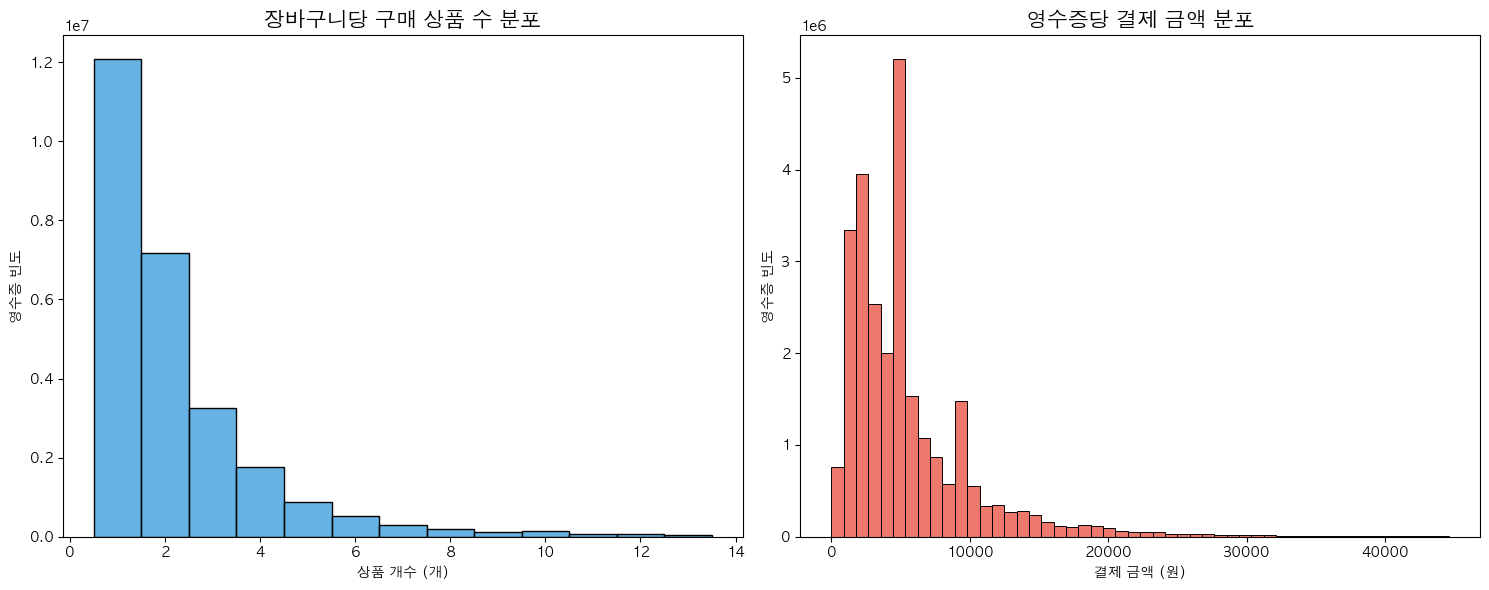

In [13]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 (Lazy)
# B2_PATH = '/Users/hajiyoon/dataset_seveneleven/B2_POS_SALE.parquet'
b2_lazy = pl.scan_parquet(B2_PATH)

print("🚀 장바구니 분석을 시작합니다... ")

# 2. 알려준 컬럼명으로 그룹화 및 집계
# 판매일자, 점포코드, POS번호, 거래번호 네 가지를 합쳐야 유니크한 영수증 한 장이 돼!
basket_agg_lazy = (
    b2_lazy
    .filter((pl.col("판매수량") > 0) & (pl.col("판매금액") > 0))
    .group_by(["판매일자", "점포코드", "POS번호", "거래번호"])
    .agg([
        pl.col("판매수량").sum().alias("basket_size"),
        pl.col("판매금액").sum().alias("ticket_size")
    ])
)

# 3. 데이터 실행 (Collect)
basket_df = basket_agg_lazy.collect()

# 4. 시각화용 데이터 정제 (상위 1% 이상치 제거)
q99_size = basket_df["basket_size"].quantile(0.99)
q99_amt = basket_df["ticket_size"].quantile(0.99)

plot_df = (
    basket_df
    .filter((pl.col("basket_size") <= q99_size) & (pl.col("ticket_size") <= q99_amt))
    .to_pandas()
)

# 5. 결과 출력 및 시각화
print("-" * 30)
print(f"✅ 분석 완료! 총 영수증: {len(basket_df):,}건")
print(f"📦 평균 구매 개수: {basket_df['basket_size'].mean():.2f}개")
print(f"💰 평균 결제 금액: {basket_df['ticket_size'].mean():,.0f}원")
print("-" * 30)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 장바구니 크기 분포
sns.histplot(plot_df['basket_size'], bins=int(q99_size), ax=axes[0], color='#3498db', discrete=True)
axes[0].set_title('장바구니당 구매 상품 수 분포', fontsize=15)
axes[0].set_xlabel('상품 개수 (개)')
axes[0].set_ylabel('영수증 빈도')

# 객단가 분포
sns.histplot(plot_df['ticket_size'], bins=50, ax=axes[1], color='#e74c3c')
axes[1].set_title('영수증당 결제 금액 분포', fontsize=15)
axes[1].set_xlabel('결제 금액 (원)')
axes[1].set_ylabel('영수증 빈도')

plt.tight_layout()
plt.show()

In [30]:
import polars as pl

# 1. 데이터 로드
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

print("💎 단가 5만 원 이상의 고가 상품 목록을 추출 중입니다...")

# 2. 단가 5만원 이상 상품 필터링 및 집계
# 상품별로 단가는 동일할 것이므로 unique를 통해 상품별 대표 단가와 총 판매수량을 가져옴
high_price_items = (
    df_lazy
    .group_by(["상품명", "중분류명"])
    .agg([
        pl.col("판매금액").first().alias("단가"), # 상품별 단가 (판매금액/판매수량과 동일)
        pl.col("판매수량").sum().alias("총판매수량"),
        (pl.col("판매금액").sum()).alias("총매출액")
    ])
    .filter(pl.col("단가") >= 50000)
    .sort("단가", descending=True)
).collect()

# 3. 결과 출력
print(f"✅ 총 {len(high_price_items)}개의 고가 상품이 발견되었습니다.")
print("-" * 50)
# 데이터가 많을 수 있으니 상위 30개만 출력
print(high_price_items.head(30))

# 4. (선택사항) CSV로 저장해서 따로 보고 싶다면 아래 주석 해제
# high_price_items.write_csv("high_price_items_list.csv")

💎 단가 5만 원 이상의 고가 상품 목록을 추출 중입니다...
✅ 총 384개의 고가 상품이 발견되었습니다.
--------------------------------------------------
shape: (30, 5)
┌─────────────────────────────────┬─────────────┬────────────┬────────────┬────────────┐
│ 상품명                          ┆ 중분류명    ┆ 단가       ┆ 총판매수량 ┆ 총매출액   │
│ ---                             ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│ str                             ┆ str         ┆ i64        ┆ i64        ┆ i64        │
╞═════════════════════════════════╪═════════════╪════════════╪════════════╪════════════╡
│ 윌리엄)글렌피딕 40년            ┆ 양주        ┆ 1300000000 ┆ 200        ┆ 2600000000 │
│ 25설특_CJ)스팸복합2호(1)        ┆ 선물세트    ┆ 22477500   ┆ 1280       ┆ 28800000   │
│ LG)프리미엄햄복합6호_25설       ┆ 선물세트    ┆ 7830300    ┆ 344        ┆ 20880800   │
│ 25설)정관장홍삼진본             ┆ 선물세트    ┆ 4700000    ┆ 188        ┆ 9400000    │
│ 25설)삼진어묵1953세트1호        ┆ 냉장간편식  ┆ 3725200    ┆ 289        ┆ 7775900    │
│ …                               ┆ …           ┆ …         

In [31]:
import polars as pl

# 1. 데이터 로드
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

print("🔍 중분류명에 '세트'가 포함된 고가 상품을 분석 중입니다...")

# 2. 단가 5만원 이상 상품 중 '세트' 키워드 필터링
high_price_base = (
    df_lazy
    .group_by(["상품명", "중분류명"])
    .agg([
        pl.col("판매금액").first().alias("단가"),
        pl.col("판매수량").sum().alias("총판매수량")
    ])
    .filter(pl.col("단가") >= 50000)
)

# 전체 고가 상품 vs '세트' 포함 고가 상품 비교
analysis_result = high_price_base.select([
    pl.len().alias("전체_고가상품_수"),
    pl.col("중분류명").str.contains("세트").sum().alias("세트_키워드_상품_수")
]).collect()

# '세트' 상품 리스트 상세 추출
set_items_list = (
    high_price_base
    .filter(pl.col("중분류명").str.contains("세트"))
    .sort("단가", descending=True)
).collect()

# 3. 결과 출력
total_high = analysis_result["전체_고가상품_수"][0]
set_high = analysis_result["세트_키워드_상품_수"][0]

print(f"✅ 결과 요약")
print(f"- 단가 5만 원 이상 전체 상품 수: {total_high}개")
print(f"- 그 중 중분류에 '세트'가 포함된 상품 수: {set_high}개 (약 {set_high/total_high*100:.1f}%)")
print("-" * 50)
print("📦 '세트' 키워드 포함 상품 상위 리스트 (단가 기준):")
print(set_items_list.head(20))

🔍 중분류명에 '세트'가 포함된 고가 상품을 분석 중입니다...
✅ 결과 요약
- 단가 5만 원 이상 전체 상품 수: 384개
- 그 중 중분류에 '세트'가 포함된 상품 수: 77개 (약 20.1%)
--------------------------------------------------
📦 '세트' 키워드 포함 상품 상위 리스트 (단가 기준):
shape: (20, 4)
┌─────────────────────────────────┬───────────┬──────────┬────────────┐
│ 상품명                          ┆ 중분류명  ┆ 단가     ┆ 총판매수량 │
│ ---                             ┆ ---       ┆ ---      ┆ ---        │
│ str                             ┆ str       ┆ i64      ┆ i64        │
╞═════════════════════════════════╪═══════════╪══════════╪════════════╡
│ 25설특_CJ)스팸복합2호(1)        ┆ 선물세트  ┆ 22477500 ┆ 1280       │
│ LG)프리미엄햄복합6호_25설       ┆ 선물세트  ┆ 7830300  ┆ 344        │
│ 25설)정관장홍삼진본             ┆ 선물세트  ┆ 4700000  ┆ 188        │
│ 바다원)명품통영멸치세트_25설    ┆ 선물세트  ┆ 3720000  ┆ 193        │
│ 25설특_동원튜나리챔30호..       ┆ 선물세트  ┆ 3250000  ┆ 200        │
│ …                               ┆ …         ┆ …        ┆ …          │
│ 25설)홍삼정에브리타임롱기스트20 ┆ 선물세트  ┆ 360000   ┆ 10         │
│ 포                  

In [16]:
print("🔍 1개만 산 영수증과 4,500원의 정체를 파악하는 중...")

# 2. 영수증 단위 집계 (상품코드를 하나 가져오기 위해 first() 사용)
basket_lazy = (
    b2_lazy
    .filter((pl.col("판매수량") > 0) & (pl.col("판매금액") > 0))
    .group_by(["판매일자", "점포코드", "POS번호", "거래번호"])
    .agg([
        pl.col("판매수량").sum().alias("basket_size"),
        pl.col("판매금액").sum().alias("ticket_size"),
        # 영수증에 상품이 1개뿐이라면, 그 상품의 코드가 저장됨
        pl.col("상품코드").first().alias("single_item_cd") 
    ])
)

basket_df = basket_lazy.collect()

# --- [분석 1] 단일 상품(1개) 결제 비율 ---
total_cnt = len(basket_df)
single_item_df = basket_df.filter(pl.col("basket_size") == 1)
single_cnt = len(single_item_df)

print(f"\n✅ 전체 영수증: {total_cnt:,}건")
print(f"✅ 딱 1개만 산 영수증: {single_cnt:,}건 ({(single_cnt/total_cnt)*100:.1f}%)")

# --- [분석 2] 딱 1개 샀을 때, 사람들이 가장 많이 결제한 금액 Top 5 ---
top_prices = (
    single_item_df
    .group_by("ticket_size")
    .agg(pl.len().alias("영수증_건수"))
    .sort("영수증_건수", descending=True)
    .head(5)
)
print("\n[딱 1개 샀을 때 가장 많이 나온 결제 금액 Top 5]")
print(top_prices)

# --- [분석 3] 가설 검증: 4,500원 결제건의 정체는? ---
# 4,500원짜리 상품코드만 추려서 B4(음식) 데이터와 맞춰보기 (Left Join)
price_4500_codes = (
    single_item_df.filter(pl.col("ticket_size") == 4500)
    .group_by("single_item_cd")
    .agg(pl.len().alias("판매건수"))
    .sort("판매건수", descending=True)
).lazy()

# B4에 이름이 있으면 '음식', 없으면(null) '담배/잡화'
check_4500_df = (
    price_4500_codes
    .join(b4_lazy.select(["ITEM_CD", "ITEM_NM"]).rename({"ITEM_CD": "single_item_cd"}), 
          on="single_item_cd", how="left")
).collect().head(5)

print("\n[4,500원짜리 단일 상품 Top 5 정체 확인]")
print(check_4500_df)

🔍 1개만 산 영수증과 4,500원의 정체를 파악하는 중...

✅ 전체 영수증: 27,039,193건
✅ 딱 1개만 산 영수증: 12,089,128건 (44.7%)

[딱 1개 샀을 때 가장 많이 나온 결제 금액 Top 5]
shape: (5, 2)
┌─────────────┬─────────────┐
│ ticket_size ┆ 영수증_건수 │
│ ---         ┆ ---         │
│ i64         ┆ u32         │
╞═════════════╪═════════════╡
│ 4500        ┆ 2755359     │
│ 4800        ┆ 593143      │
│ 1200        ┆ 577896      │
│ 1800        ┆ 514650      │
│ 1000        ┆ 477258      │
└─────────────┴─────────────┘

[4,500원짜리 단일 상품 Top 5 정체 확인]
shape: (5, 3)
┌────────────────┬──────────┬─────────┐
│ single_item_cd ┆ 판매건수 ┆ ITEM_NM │
│ ---            ┆ ---      ┆ ---     │
│ str            ┆ u32      ┆ str     │
╞════════════════╪══════════╪═════════╡
│ 314631         ┆ 130869   ┆ null    │
│ 300112         ┆ 111278   ┆ null    │
│ 314767         ┆ 82273    ┆ null    │
│ 300115         ┆ 80682    ┆ null    │
│ 314988         ┆ 79927    ┆ null    │
└────────────────┴──────────┴─────────┘


다중 구매 식품 장바구니 데이터 마트(Data Mart) 구축

장바구니 크기가 2 이상인 영수증만 추출하고, 식품 마스터(B4) 데이터와 결합하여 비식품 데이터를 완전히 배제

In [20]:
OUT_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
print("🧹 노이즈(1개 구매, 비식품) 제거 및 데이터 마트 구축 중...")

# 3. 유효 데이터 필터링 (환불 건 제외)
b2_valid = b2_lazy.filter((pl.col("판매수량") > 0) & (pl.col("판매금액") > 0))

# 4. 다중 구매(2개 이상) 영수증 키값만 추출
receipt_keys = ["판매일자", "점포코드", "POS번호", "거래번호"]

multi_baskets = (
    b2_valid
    .group_by(receipt_keys)
    .agg(pl.col("판매수량").sum().alias("basket_size"))
    .filter(pl.col("basket_size") >= 2)
    .select(receipt_keys) # 영수증 번호 4종 세트만 남김
)

# 5. 최종 데이터 마트 결합 (Inner Join)
# B2 ∩ (2개 이상 영수증) ∩ (식품 마스터)
data_mart_lazy = (
    b2_valid
    .join(multi_baskets, on=receipt_keys, how="inner") # 1개 산 영수증 탈락!
    .join(b4_lazy, on="상품코드", how="inner")   # 담배 등 비식품 탈락!
)

# 6. 실행 및 새로운 Parquet 파일로 저장
data_mart_df = data_mart_lazy.collect()
data_mart_df.write_parquet(OUT_PATH)

print(f"✅ 알짜배기 데이터 마트 구축 완료!")
print(f"💾 저장 경로: {OUT_PATH}")
print(f"📉 남은 데이터 건수: {len(data_mart_df):,}건")
print("\n[미리보기]")
print(data_mart_df.select(["판매일자", "상품코드", "상품명", "중분류명", "판매수량"]).head(5))

🧹 노이즈(1개 구매, 비식품) 제거 및 데이터 마트 구축 중...
✅ 알짜배기 데이터 마트 구축 완료!
💾 저장 경로: /Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet
📉 남은 데이터 건수: 22,991,253건

[미리보기]
shape: (5, 5)
┌──────────┬──────────┬────────────────────────────────┬──────────┬──────────┐
│ 판매일자 ┆ 상품코드 ┆ 상품명                         ┆ 중분류명 ┆ 판매수량 │
│ ---      ┆ ---      ┆ ---                            ┆ ---      ┆ ---      │
│ str      ┆ str      ┆ str                            ┆ str      ┆ i64      │
╞══════════╪══════════╪════════════════════════════════╪══════════╪══════════╡
│ 20250523 ┆ 117969   ┆ 오리온)고소미70g               ┆ 비스킷류 ┆ 1        │
│ 20250523 ┆ 124518   ┆ 오리온)코코망고알맹이67g       ┆ 젤리류   ┆ 1        │
│ 20250523 ┆ 116368   ┆ 오리온)꼬북칩콘스프맛80g       ┆ 스낵류   ┆ 1        │
│ 20250523 ┆ 117048   ┆ 오리온)태양의맛썬핫스파이시80g ┆ 스낵류   ┆ 1        │
│ 20250523 ┆ 180036   ┆ 오비)카스500ml캔               ┆ 국산맥주 ┆ 4        │
└──────────┴──────────┴────────────────────────────────┴──────────┴──────────┘


🕒 시간대 및 요일별 트렌드를 분석 중입니다...
✅ 집계 완료! 시각화를 시작합니다.


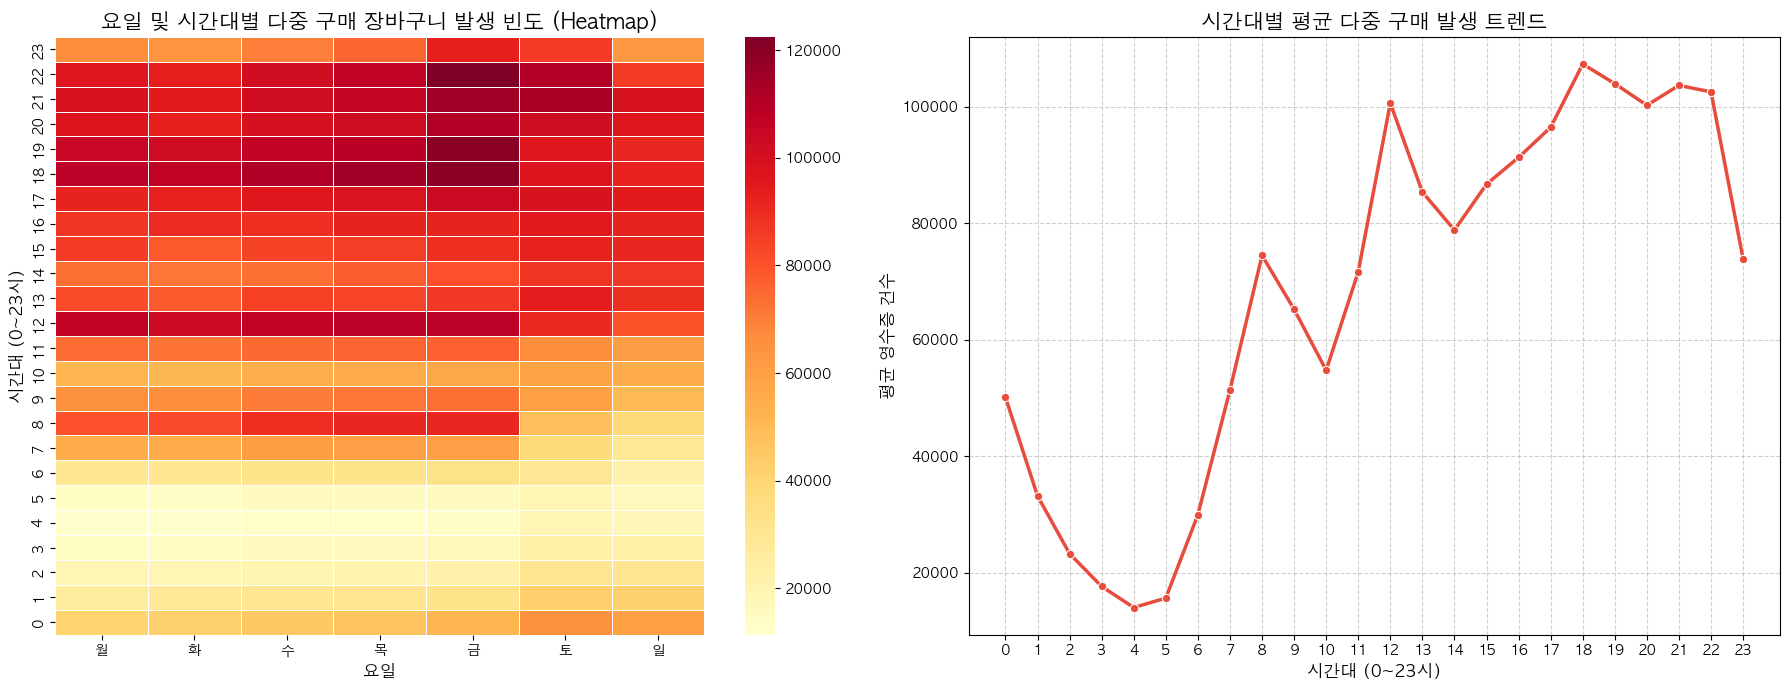

In [23]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 클린 데이터 마트 로드 (지윤이의 새로운 경로 적용!)
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
data_mart_lazy = pl.scan_parquet(DATA_MART_PATH)

print("🕒 시간대 및 요일별 트렌드를 분석 중입니다...")

# 2. 날짜 및 시간 데이터 전처리
receipt_keys = ["판매일자", "점포코드", "POS번호", "거래번호"]

time_trend_lazy = (
    data_mart_lazy
    .select(receipt_keys + ["판매시간"])
    .unique(subset=receipt_keys) # 영수증 1장당 1줄로 압축!
    .with_columns([
        # 1. 판매일자 -> 요일 추출 (최신 문법인 to_date 사용)
        pl.col("판매일자")
        .cast(pl.Utf8)
        .str.replace_all("-", "")
        .str.to_date("%Y%m%d") 
        .dt.weekday()
        .alias("weekday_num"),
        
        # 2. 판매시간 -> 시간(Hour) 추출 ('143000' -> 14)
        pl.col("판매시간")
        .cast(pl.Utf8)
        .str.zfill(6)
        .str.slice(0, 2)
        .cast(pl.Int32)
        .alias("hour")
    ])
    # 3. 요일 이름 매핑 (안전하게 문자열로 변환 후 매핑)
    .with_columns(
        pl.col("weekday_num")
        .cast(pl.Utf8)
        .replace(
            {"1": "월", "2": "화", "3": "수", "4": "목", "5": "금", "6": "토", "7": "일"}
        ).alias("weekday")
    )
)

# 3. 요일 & 시간대별 영수증 건수 집계
heatmap_data = (
    time_trend_lazy
    .group_by(["weekday", "hour"])
    .agg(pl.len().alias("receipt_count"))
    .collect()
    .to_pandas()
)

print("✅ 집계 완료! 시각화를 시작합니다.")

# 4. 시각화를 위한 데이터 피벗 (Pivot)
pivot_df = heatmap_data.pivot(index="hour", columns="weekday", values="receipt_count").fillna(0)

# 요일 순서 정렬
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]
pivot_df = pivot_df.reindex(columns=weekday_order).sort_index()

# 5. 시각화 그리기
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 그래프 1: 요일 vs 시간대 히트맵
sns.heatmap(pivot_df, cmap="YlOrRd", ax=axes[0], linewidths=.5, annot=False)
axes[0].set_title('요일 및 시간대별 다중 구매 장바구니 발생 빈도 (Heatmap)', fontsize=15)
axes[0].set_xlabel('요일', fontsize=12)
axes[0].set_ylabel('시간대 (0~23시)', fontsize=12)
axes[0].invert_yaxis()

# 그래프 2: 시간대별 전체 평균 트렌드
hourly_trend = heatmap_data.groupby('hour')['receipt_count'].mean().reset_index()
sns.lineplot(data=hourly_trend, x='hour', y='receipt_count', marker='o', color='#e74c3c', ax=axes[1], linewidth=2.5)
axes[1].set_title('시간대별 평균 다중 구매 발생 트렌드', fontsize=15)
axes[1].set_xlabel('시간대 (0~23시)', fontsize=12)
axes[1].set_ylabel('평균 영수증 건수', fontsize=12)
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

1. 주요 생활 패턴에 따른 피크 타임 형성
선 그래프와 히트맵을 확인하면 오전 8시, 낮 12시, 18시~22시 구간에서 장바구니 결제 건수가 급증한다. 이는 소비자의 출근, 점심, 퇴근 생활 주기와 일치하며, 다중 구매 현상이 일상적인 시간표에 크게 의존함을 나타낸다.

2. 평일 저녁 및 야식 시간대의 압도적 볼륨
히트맵 상 평일 18시에서 22시 사이가 가장 짙은 색을 띠며, 선 그래프에서도 18시 이후 10만 건 이상의 최고 볼륨이 유지된다. 퇴근길 저녁 식사, 야식, 주류 등 객단가를 높이는 연관 상품의 동시 구매가 가장 활발히 일어나는 핵심 시간대다.

3. 평일과 주말의 수요 분산 차이
주중(월~금)에는 아침 8시와 낮 12시에 짙은 가로줄 패턴이 뚜렷하게 나타나지만, 주말(토, 일)에는 이러한 오전 피크가 소멸한다. 주말은 특정 시간에 수요가 몰리기보다 오후 시간대 전반에 걸쳐 완만하게 소비가 분산되는 경향을 보인다.

🌙 평일 저녁(18~22시) 핵심 조합을 추출하고 있습니다...
✅ 동시 구매 조합 계산 완료! 히트맵을 그립니다.


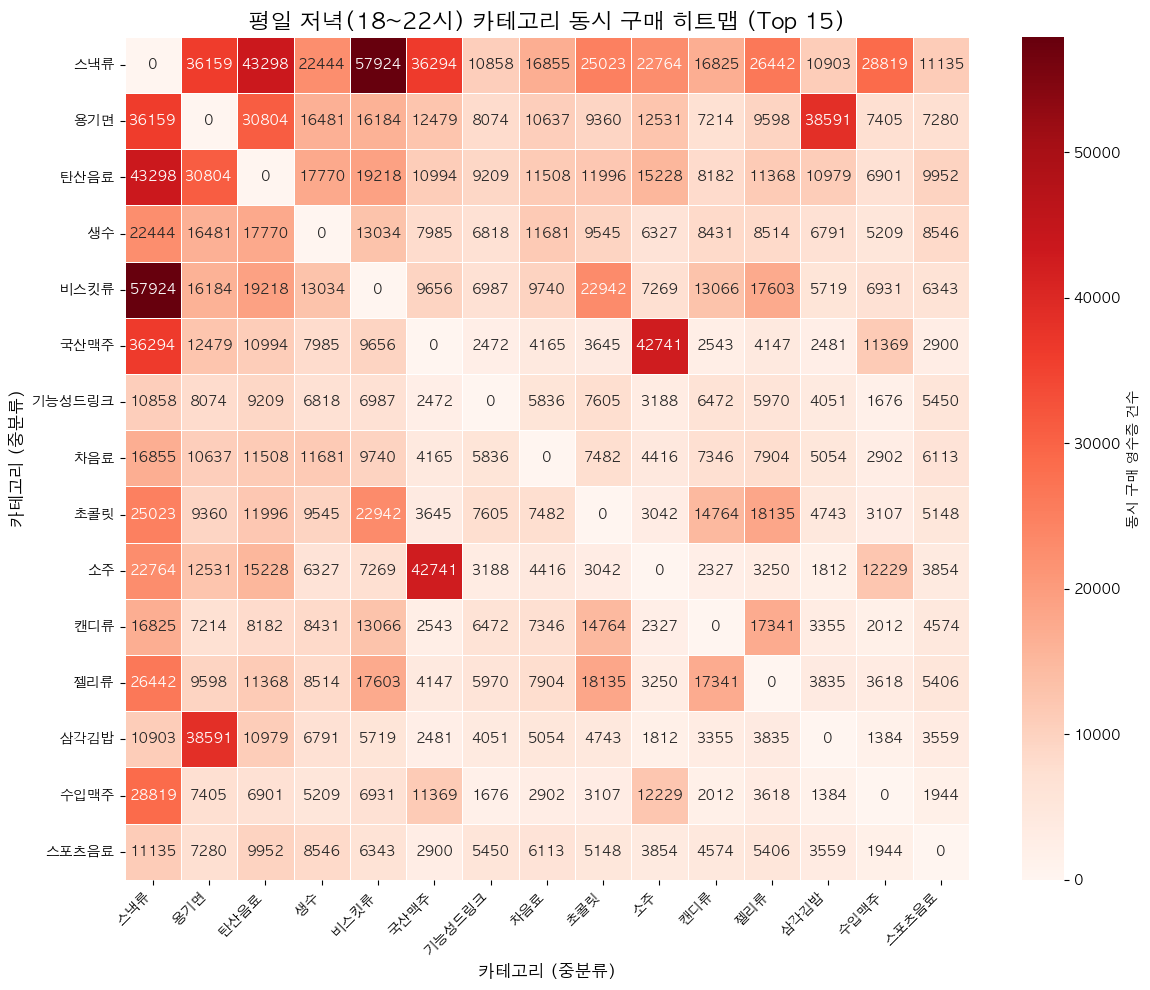

In [ ]:
# 수요 폭발하는 평일 저녁 18~22시에 사람들이 어떤 중분류 조합을 동시에 사는가? 
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False


print("🌙 평일 저녁(18~22시) 핵심 조합을 추출하고 있습니다...")

# 1. 평일(월~금) & 저녁 18~22시 데이터만 필터링
receipt_keys = ["판매일자", "점포코드", "POS번호", "거래번호"]

filtered_lazy = (
    data_mart_lazy
    .with_columns([
        pl.col("판매일자").cast(pl.Utf8).str.replace_all("-", "").str.to_date("%Y%m%d").dt.weekday().alias("weekday_num"),
        pl.col("판매시간").cast(pl.Utf8).str.zfill(6).str.slice(0, 2).cast(pl.Int32).alias("hour")
    ])
    .filter(
        (pl.col("weekday_num") <= 5) & # 1(월) ~ 5(금)
        (pl.col("hour") >= 18) & (pl.col("hour") <= 22)
    )
)

# 2. 영수증 1장 내의 카테고리 중복 제거 (예: 과자 2개 샀어도 '과자' 1번으로 카운트)
receipt_categories = (
    filtered_lazy
    .select(receipt_keys + ["중분류명"])
    .unique()
).collect()

# 3. Top 15 잘 팔리는 카테고리 추출 (히트맵 가독성을 위해)
top_15_cats = (
    receipt_categories
    .group_by("중분류명").agg(pl.len().alias("cnt"))
    .sort("cnt", descending=True)
    .head(15)["중분류명"].to_list()
)

# 4. 동일 영수증 내 카테고리 쌍(Pair) 만들기 (Self Join)
pairs = (
    receipt_categories.lazy()
    .rename({"중분류명": "cat_A"})
    .join(
        receipt_categories.lazy().rename({"중분류명": "cat_B"}),
        on=receipt_keys,
        how="inner"
    )
    # A < B 조건으로 중복(과자-음료, 음료-과자) 및 자기자신(과자-과자) 제거
    .filter(pl.col("cat_A") < pl.col("cat_B"))
    .group_by(["cat_A", "cat_B"])
    .agg(pl.len().alias("co_purchase_count"))
).collect().to_pandas()

# 5. Top 15 카테고리만 필터링
pairs_top15 = pairs[
    pairs['cat_A'].isin(top_15_cats) & pairs['cat_B'].isin(top_15_cats)
]

print("✅ 동시 구매 조합 계산 완료! 히트맵을 그립니다.")

# 6. 히트맵을 위한 대칭 행렬(Symmetric Matrix) 만들기
heatmap_df = pairs_top15.pivot(index="cat_A", columns="cat_B", values="co_purchase_count").fillna(0)

# 부족한 행/열 채워주기
for cat in top_15_cats:
    if cat not in heatmap_df.columns: heatmap_df[cat] = 0
    if cat not in heatmap_df.index: heatmap_df.loc[cat] = 0

# 인덱스와 컬럼을 Top 15 순서대로 정렬
heatmap_df = heatmap_df.reindex(index=top_15_cats, columns=top_15_cats).fillna(0)

# 대칭 행렬 완성 (A-B 값을 B-A에도 똑같이 복사)
heatmap_df = heatmap_df + heatmap_df.T

# 자기 자신과의 교차점(대각선)은 시각화를 위해 NaN 처리 (회색으로 표시됨)
np.fill_diagonal(heatmap_df.values, np.nan)

# 7. 시각화 (Seaborn Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, cmap="Reds", annot=True, fmt=".0f", 
            linewidths=.5, cbar_kws={'label': '동시 구매 영수증 건수'})
plt.title('평일 저녁(18~22시) 카테고리 동시 구매 히트맵 (Top 15)', fontsize=16)
plt.xlabel('카테고리 (중분류)', fontsize=12)
plt.ylabel('카테고리 (중분류)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

💡 평일 저녁 핵심 인사이트 Top 3
1. 압도적인 1위 조합: '스낵 & 비스킷 & 탄산음료'의 시너지
- 가장 색이 진하고 숫자가 높은 곳을 보면 스낵류 ↔ 비스킷류 (57,924건), 그리고 **스낵류 ↔ 탄산음료 (43,298건)**임.


2. 퇴근길 주류 및 안주 커뮤니티: '소맥'과 '맥주+스낵'
- 국산맥주 ↔ 소주 (42,741건) 조합이 무려 전체 3위. 퇴근 후 집에서 소맥 즐기나봄

- 또한 국산맥주 ↔ 스낵류 (36,294건). 맥주를 살 때 가장 많이 곁들이는 안주는 마른안주나 육가공류가 아니라 '스낵(과자)'.

3. 불패의 식사 대용 클래식: '용기면 + 삼각김밥'
- 용기면(컵라면) ↔ 삼각김밥 (38,591건) 조합.

📊 weekday 기준 시각화를 시작합니다...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from font(s) AppleGothi

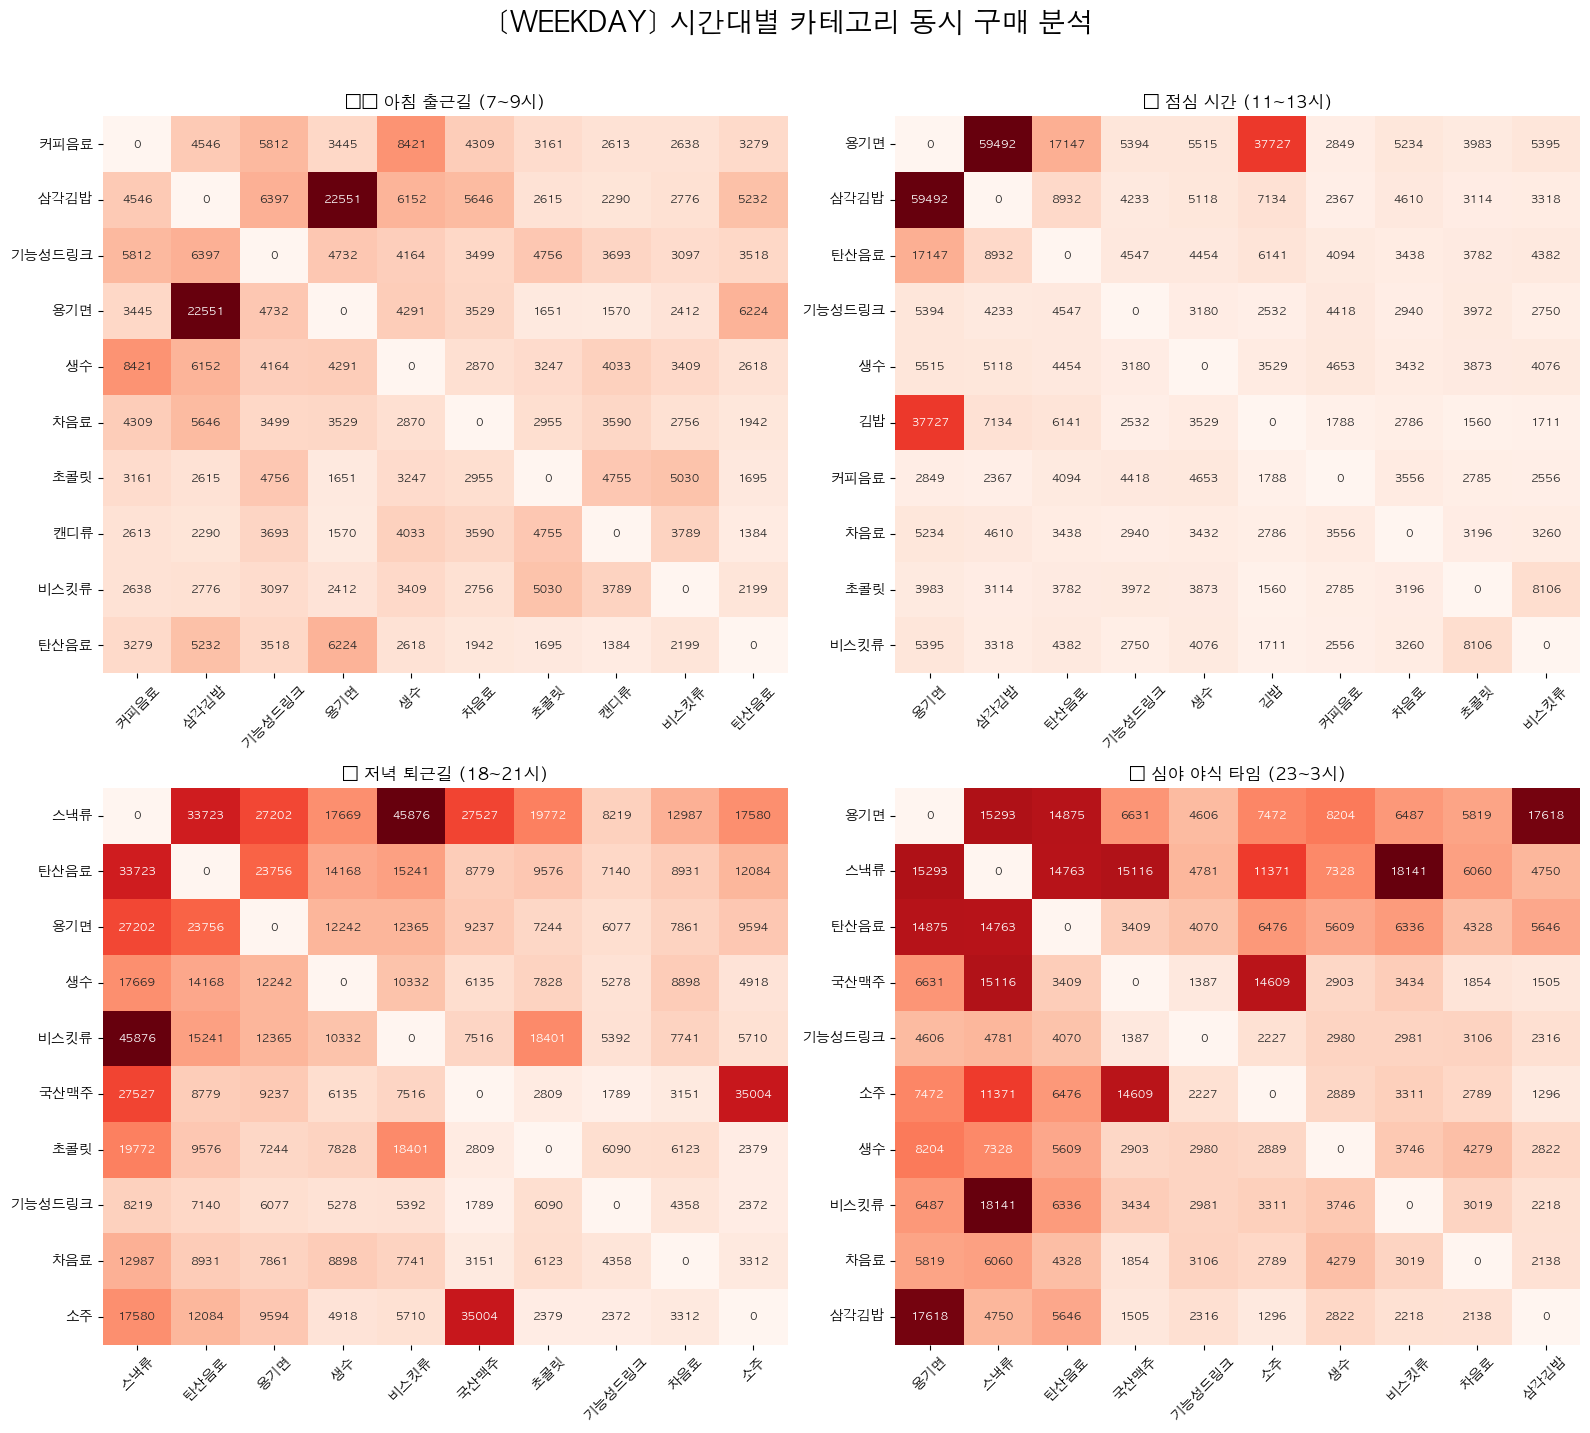

In [25]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 경로 및 설정
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
TARGET_DAYS = "weekday"  # "weekday"(평일), "weekend"(주말), "all"(전체) 중 선택

def analyze_category_heatmap(df_lazy, start_hour, end_hour, title, target_days="all", ax=None):
    # 요일 및 시간 전처리
    receipt_keys = ["판매일자", "점포코드", "POS번호", "거래번호"]
    
    # 시간대 및 요일 필터링 로직
    temp_lazy = df_lazy.with_columns([
        pl.col("판매일자").cast(pl.Utf8).str.to_date("%Y%m%d").dt.weekday().alias("weekday_num"),
        pl.col("판매시간").cast(pl.Utf8).str.zfill(6).str.slice(0, 2).cast(pl.Int32).alias("hour")
    ])
    
    if target_days == "weekday":
        temp_lazy = temp_lazy.filter(pl.col("weekday_num") <= 5)
    elif target_days == "weekend":
        temp_lazy = temp_lazy.filter(pl.col("weekday_num") > 5)
        
    # 시간 필터링 (심야 시간 23~04시 처리를 위해 범위 조정)
    if start_hour > end_hour: # 심야 시간용 (예: 23시 ~ 04시)
        temp_lazy = temp_lazy.filter((pl.col("hour") >= start_hour) | (pl.col("hour") <= end_hour))
    else:
        temp_lazy = temp_lazy.filter((pl.col("hour") >= start_hour) & (pl.col("hour") <= end_hour))

    # 영수증별 중분류명 유니크 추출
    receipt_categories = temp_lazy.select(receipt_keys + ["중분류명"]).unique().collect()
    
    if len(receipt_categories) == 0:
        print(f"⚠️ {title} 구간에 데이터가 없습니다.")
        return

    # Top 10 카테고리 추출
    top_10 = (
        receipt_categories.group_by("중분류명").agg(pl.len().alias("cnt"))
        .sort("cnt", descending=True).head(10)["중분류명"].to_list()
    )
    
    # Self Join으로 쌍(Pair) 계산
    pairs = (
        receipt_categories.lazy().rename({"중분류명": "cat_A"})
        .join(receipt_categories.lazy().rename({"중분류명": "cat_B"}), on=receipt_keys, how="inner")
        .filter(pl.col("cat_A") < pl.col("cat_B"))
        .group_by(["cat_A", "cat_B"]).agg(pl.len().alias("co_purchase_count"))
    ).collect().to_pandas()
    
    # 히트맵 매트릭스 생성
    pairs_top = pairs[pairs['cat_A'].isin(top_10) & pairs['cat_B'].isin(top_10)]
    matrix = pairs_top.pivot(index="cat_A", columns="cat_B", values="co_purchase_count").fillna(0)
    
    for cat in top_10:
        if cat not in matrix.columns: matrix[cat] = 0
        if cat not in matrix.index: matrix.loc[cat] = 0
    matrix = matrix.reindex(index=top_10, columns=top_10).fillna(0)
    matrix = matrix + matrix.T
    np.fill_diagonal(matrix.values, np.nan)
    
    # 시각화
    sns.heatmap(matrix, cmap="Reds", annot=True, fmt=".0f", ax=ax, cbar=False, annot_kws={"size": 8})
    ax.set_title(f"{title} ({start_hour}~{end_hour}시)", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=45)

# 🚀 실행부
data_mart_lazy = pl.scan_parquet(DATA_MART_PATH)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

time_periods = [
    (7, 9, "☀️ 아침 출근길"),
    (11, 13, "🍱 점심 시간"),
    (18, 21, "🌙 저녁 퇴근길"),
    (23, 3, "🦉 심야 야식 타임")
]

print(f"📊 {TARGET_DAYS} 기준 시각화를 시작합니다...")
for i, (start, end, title) in enumerate(time_periods):
    analyze_category_heatmap(data_mart_lazy, start, end, title, target_days=TARGET_DAYS, ax=axes[i])

plt.suptitle(f"[{TARGET_DAYS.upper()}] 시간대별 카테고리 동시 구매 분석", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

📊 weekend 기준 시각화를 시작합니다...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from font(s) AppleGothi

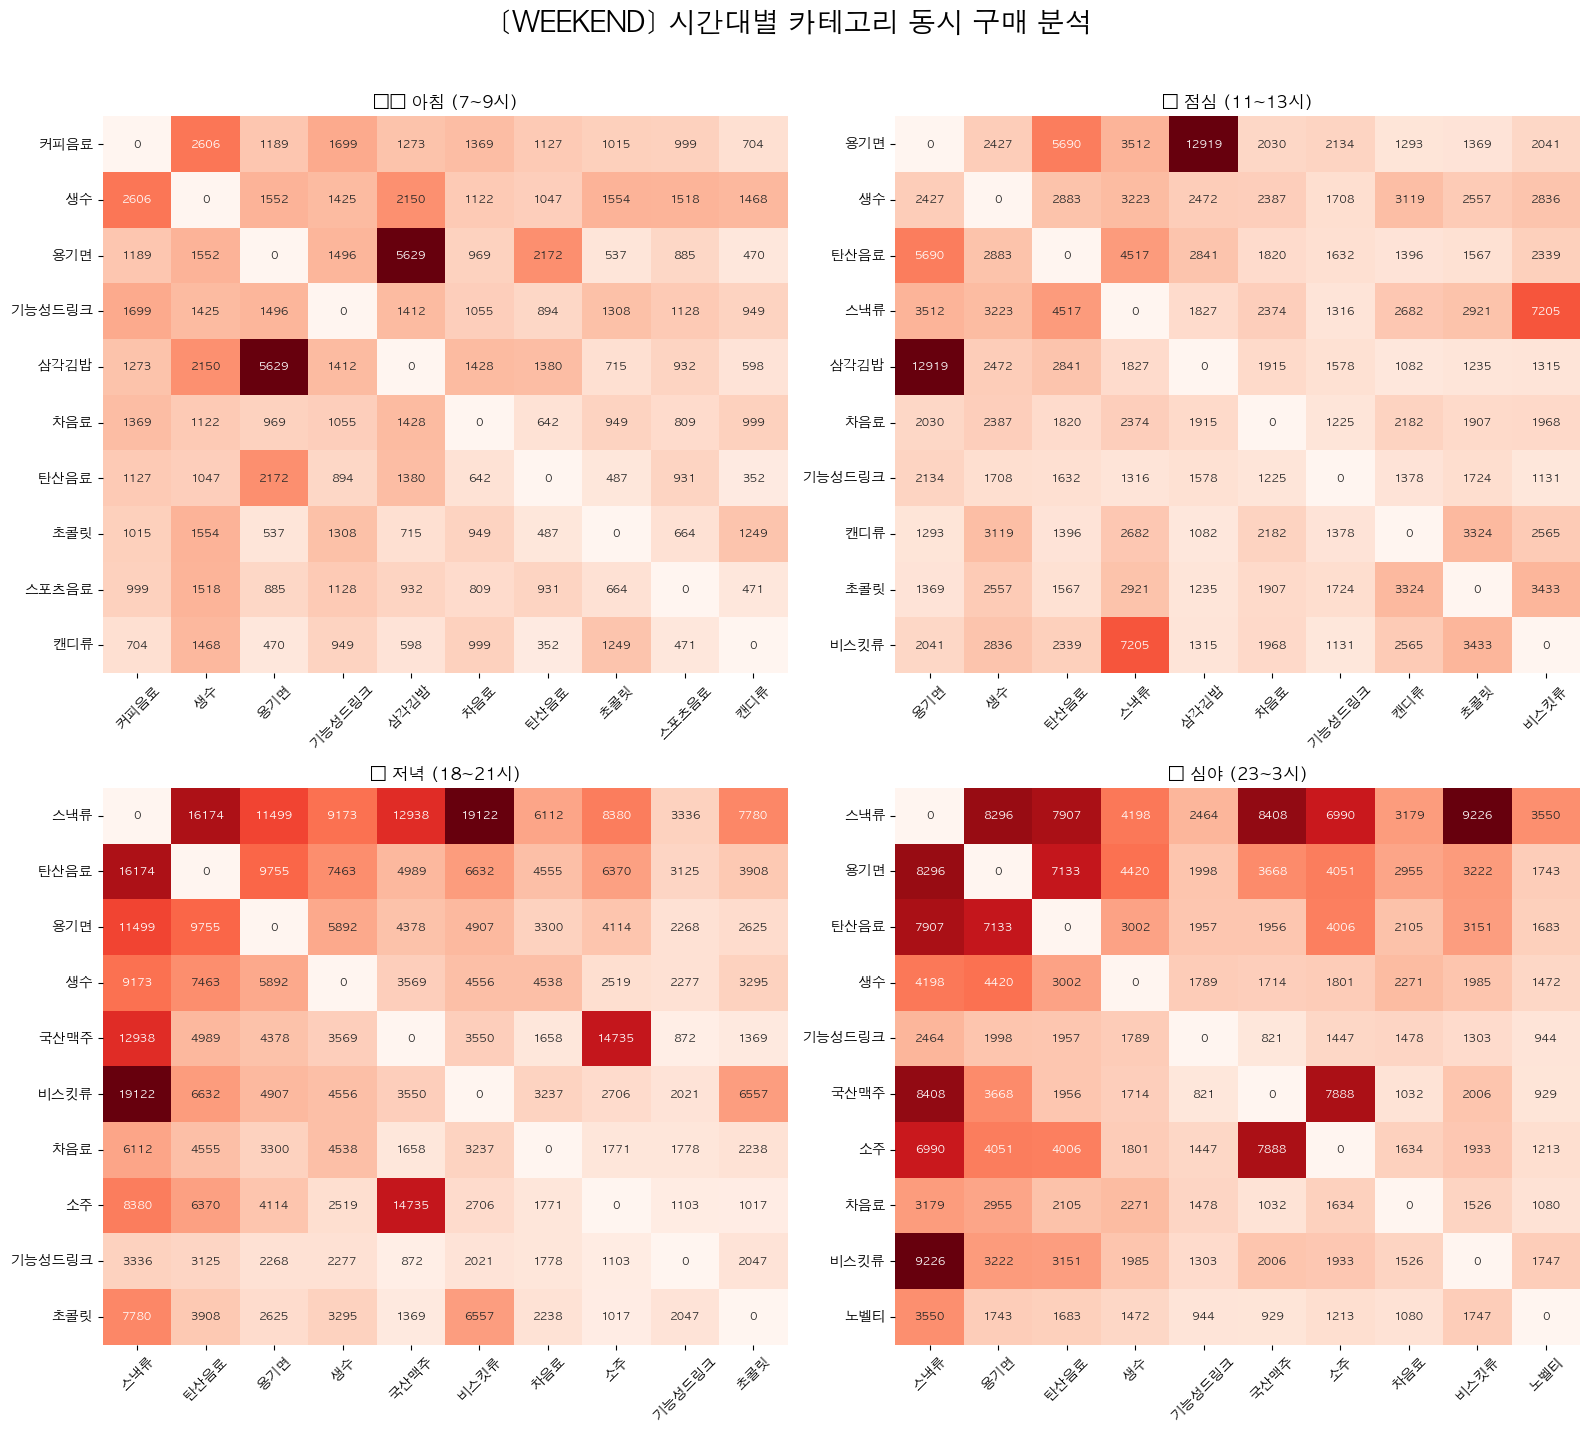

In [27]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 경로 및 설정
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
TARGET_DAYS = "weekend"  # "weekday"(평일), "weekend"(주말), "all"(전체) 중 선택

def analyze_category_heatmap(df_lazy, start_hour, end_hour, title, target_days="all", ax=None):
    # 요일 및 시간 전처리
    receipt_keys = ["판매일자", "점포코드", "POS번호", "거래번호"]
    
    # 시간대 및 요일 필터링 로직
    temp_lazy = df_lazy.with_columns([
        pl.col("판매일자").cast(pl.Utf8).str.to_date("%Y%m%d").dt.weekday().alias("weekday_num"),
        pl.col("판매시간").cast(pl.Utf8).str.zfill(6).str.slice(0, 2).cast(pl.Int32).alias("hour")
    ])
    
    if target_days == "weekday":
        temp_lazy = temp_lazy.filter(pl.col("weekday_num") <= 5)
    elif target_days == "weekend":
        temp_lazy = temp_lazy.filter(pl.col("weekday_num") > 5)
        
    # 시간 필터링 (심야 시간 23~04시 처리를 위해 범위 조정)
    if start_hour > end_hour: # 심야 시간용 (예: 23시 ~ 04시)
        temp_lazy = temp_lazy.filter((pl.col("hour") >= start_hour) | (pl.col("hour") <= end_hour))
    else:
        temp_lazy = temp_lazy.filter((pl.col("hour") >= start_hour) & (pl.col("hour") <= end_hour))

    # 영수증별 중분류명 유니크 추출
    receipt_categories = temp_lazy.select(receipt_keys + ["중분류명"]).unique().collect()
    
    if len(receipt_categories) == 0:
        print(f"⚠️ {title} 구간에 데이터가 없습니다.")
        return

    # Top 10 카테고리 추출
    top_10 = (
        receipt_categories.group_by("중분류명").agg(pl.len().alias("cnt"))
        .sort("cnt", descending=True).head(10)["중분류명"].to_list()
    )
    
    # Self Join으로 쌍(Pair) 계산
    pairs = (
        receipt_categories.lazy().rename({"중분류명": "cat_A"})
        .join(receipt_categories.lazy().rename({"중분류명": "cat_B"}), on=receipt_keys, how="inner")
        .filter(pl.col("cat_A") < pl.col("cat_B"))
        .group_by(["cat_A", "cat_B"]).agg(pl.len().alias("co_purchase_count"))
    ).collect().to_pandas()
    
    # 히트맵 매트릭스 생성
    pairs_top = pairs[pairs['cat_A'].isin(top_10) & pairs['cat_B'].isin(top_10)]
    matrix = pairs_top.pivot(index="cat_A", columns="cat_B", values="co_purchase_count").fillna(0)
    
    for cat in top_10:
        if cat not in matrix.columns: matrix[cat] = 0
        if cat not in matrix.index: matrix.loc[cat] = 0
    matrix = matrix.reindex(index=top_10, columns=top_10).fillna(0)
    matrix = matrix + matrix.T
    np.fill_diagonal(matrix.values, np.nan)
    
    # 시각화
    sns.heatmap(matrix, cmap="Reds", annot=True, fmt=".0f", ax=ax, cbar=False, annot_kws={"size": 8})
    ax.set_title(f"{title} ({start_hour}~{end_hour}시)", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=45)

# 🚀 실행부
data_mart_lazy = pl.scan_parquet(DATA_MART_PATH)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

time_periods = [
    (7, 9, "☀️ 아침"),
    (11, 13, "🍱 점심"),
    (18, 21, "🌙 저녁"),
    (23, 3, "🦉 심야")
]

print(f"📊 {TARGET_DAYS} 기준 시각화를 시작합니다...")
for i, (start, end, title) in enumerate(time_periods):
    analyze_category_heatmap(data_mart_lazy, start, end, title, target_days=TARGET_DAYS, ax=axes[i])

plt.suptitle(f"[{TARGET_DAYS.upper()}] 시간대별 카테고리 동시 구매 분석", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

평일은 출근, 점심, 퇴근이라는 직장인/학생의 **루틴(Routine)**에 따라 장바구니가 움직인다.

1. 아침(07~09시): [삼각김밥 ↔ 용기면] 조합이 압도적. 바쁜 아침을 빠르게 해결하려는 가성비 식사 수요가 매우 강력함.

2. 점심(11~13시): [김밥 ↔ 용기면] 조합이 피크를 찍음. 아침보다 '김밥'의 비중이 높아지며 탄수화물+국물 조합의 정석을 보여줌.

3. 저녁(18~21시): [스낵 ↔ 비스킷] 및 [소주 ↔ 국산맥주] 조합이 급증. 퇴근 후 보상 심리로 인한 간식 및 주류(소맥) 수요가 집중됨.


주말은 평일의 루틴이 붕괴되며, 가정 내 체류 시간과 여가 활동에 따른 변화가 뚜렷하다.

1. 아침(07~09시): 평일 대비 전체적인 결제 볼륨이 급감하며 색이 연해짐. 목적성 식사 수요가 사라지고 완만한 소비 형태를 보임.

2. 저녁(18~21시): **[국산맥주 ↔ 소주]**의 결합 강도가 평일보다 더 짙어짐. 특히 [스낵 ↔ 국산맥주] 조합이 강화되며 '홈술(Home-drinking)' 트렌드가 극대화됨.

3. 심야(23~03시): 평일보다 **[스낵 ↔ 비스킷]**과 같은 마른안주류 조합의 지속성이 높음. 주말 밤을 즐기는 올빼미족의 야식 패턴이 두드러짐.


<인사이트 >
1. 전략적 진열: 평일 오전에는 [용기면-삼각김밥] 매대를 밀착 배치하고, 주말 오후에는 [맥주-스낵] 대용량 번들 프로모션을 강화해야 함.

2. 타겟팅 차별화: 평일은 '빠른 식사' 키워드, 주말은 '즐거운 야식/안주' 키워드로 연관 상품 추천 알고리즘을 설계하는 것이 유리함.

3. 데이터 클렌징 성과: 담배 등 비식품 노이즈를 제거함으로써, [소주-맥주]와 같은 순수 식품 간의 강력한 보완재 관계를 명확히 입증함.

💰 상품별 매출 기여도를 분석 중입니다...
✅ 분석 완료! 전체 상품 수: 7,392개
🎯 상위 20% 상품(1,478개)이 전체 매출의 약 83.4%를 차지합니다!


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/704179904.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


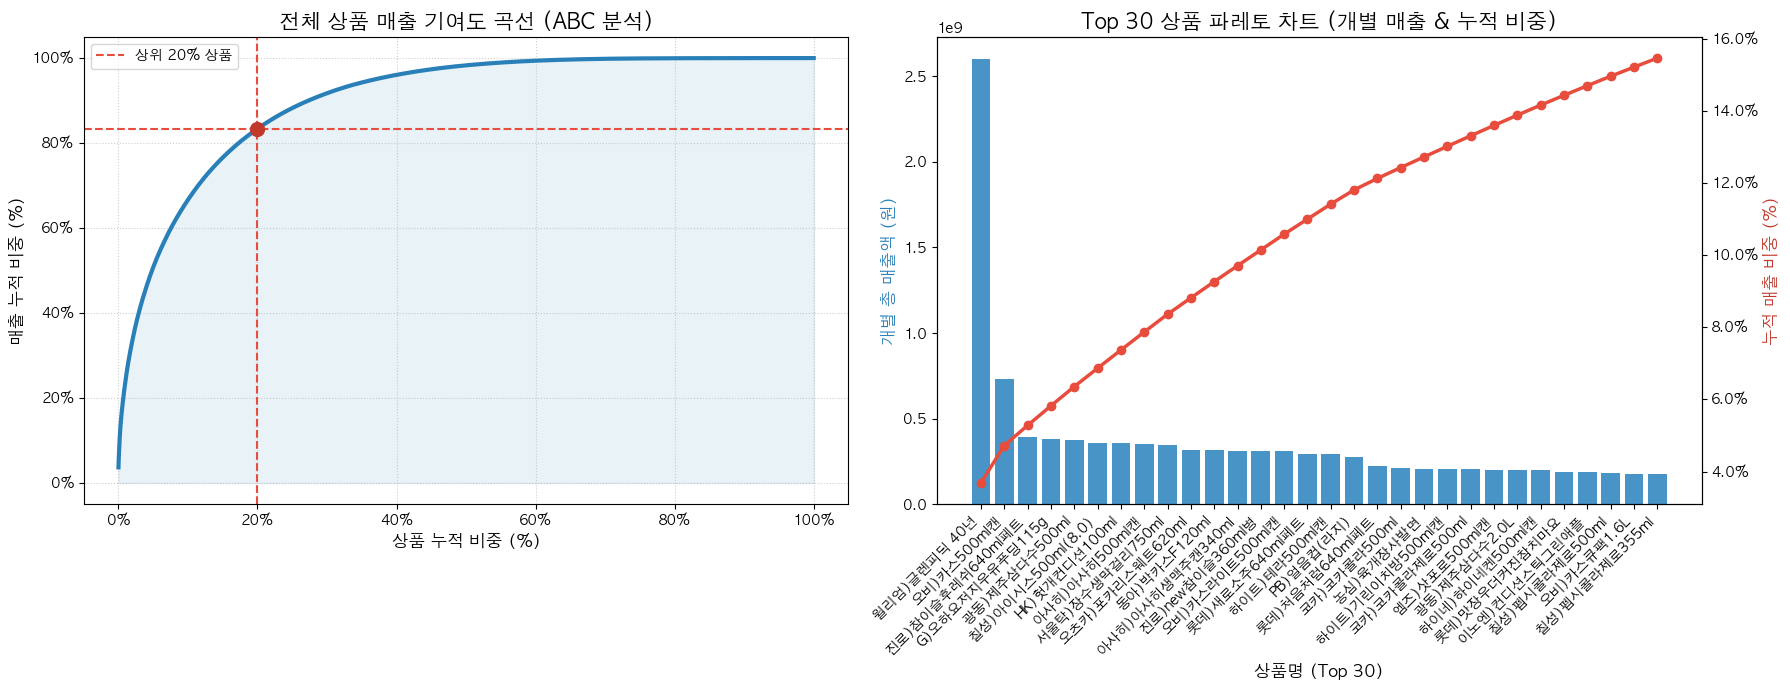

In [28]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

print("💰 상품별 매출 기여도를 분석 중입니다...")

# 2. 상품별 총 판매금액 집계 및 정렬
product_sales_lazy = (
    df_lazy
    .group_by("상품명")
    .agg(pl.col("판매금액").sum().alias("총매출액"))
    .sort("총매출액", descending=True)
)

product_sales = product_sales_lazy.collect()

# 3. 파레토 분석을 위한 누적 데이터 계산
total_revenue = product_sales["총매출액"].sum()
total_items = len(product_sales)

# Polars로 누적 합계(Cumsum) 및 비율 계산
pareto_df = (
    product_sales
    .with_columns([
        pl.col("총매출액").cum_sum().alias("누적매출액")
    ])
    .with_columns([
        (pl.col("누적매출액") / total_revenue * 100).alias("누적매출비중(%)"),
        (pl.Series(range(1, total_items + 1)) / total_items * 100).alias("상품누적비중(%)")
    ])
).to_pandas()

# 상위 20% 상품이 차지하는 매출 비중 찾기
top_20_sales_pct = pareto_df[pareto_df['상품누적비중(%)'] <= 20]['누적매출비중(%)'].max()
top_20_item_cnt = int(total_items * 0.2)

print(f"✅ 분석 완료! 전체 상품 수: {total_items:,}개")
print(f"🎯 상위 20% 상품({top_20_item_cnt:,}개)이 전체 매출의 약 {top_20_sales_pct:.1f}%를 차지합니다!")

# 4. 시각화 (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 그래프 1: 전체 상품 로렌츠 곡선 (ABC 분석) ---
axes[0].plot(pareto_df['상품누적비중(%)'], pareto_df['누적매출비중(%)'], color='#2980b9', linewidth=3)
axes[0].fill_between(pareto_df['상품누적비중(%)'], pareto_df['누적매출비중(%)'], alpha=0.1, color='#2980b9')
axes[0].axvline(x=20, color='#e74c3c', linestyle='--', label='상위 20% 상품')
axes[0].axhline(y=top_20_sales_pct, color='#e74c3c', linestyle='--')
axes[0].scatter(20, top_20_sales_pct, color='#c0392b', s=100, zorder=5)

axes[0].set_title('전체 상품 매출 기여도 곡선 (ABC 분석)', fontsize=15)
axes[0].set_xlabel('상품 누적 비중 (%)', fontsize=12)
axes[0].set_ylabel('매출 누적 비중 (%)', fontsize=12)
axes[0].xaxis.set_major_formatter(PercentFormatter())
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- 그래프 2: Top 30 상품 파레토 차트 ---
top_30 = pareto_df.head(30)
ax2 = axes[1]
ax3 = ax2.twinx() # 이중 Y축 생성

# 막대 차트 (개별 매출)
sns.barplot(data=top_30, x='상품명', y='총매출액', color='#3498db', ax=ax2)
# 꺾은선 차트 (누적 매출 비중)
ax3.plot(top_30.index, top_30['누적매출비중(%)'], color='#e74c3c', marker='o', linewidth=2.5)

ax2.set_title('Top 30 상품 파레토 차트 (개별 매출 & 누적 비중)', fontsize=15)
ax2.set_xlabel('상품명 (Top 30)', fontsize=12)
ax2.set_ylabel('개별 총 매출액 (원)', fontsize=12, color='#2980b9')
ax3.set_ylabel('누적 매출 비중 (%)', fontsize=12, color='#c0392b')
ax3.yaxis.set_major_formatter(PercentFormatter())

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(False) # 막대 차트 배경 그리드 제거

plt.tight_layout()
plt.show()

1. 파레토(ABC) 시각화 - 매출액기준 결과 분석

- 파레토 법칙 검증: 전체 7,392개 상품 중 상위 20%(1,478개)가 전체 매출의 83.4%를 차지하는 것으로 나타났다. 소수의 핵심 상품군이 매장 전체의 수익을 견인하는 수익 집중화 구조가 확인된다.

- 고단가 이상치(Outlier) 발견: 개별 매출액 1위로 나타난 '윌리엄)글렌피딕 40년'은 일반적인 편의점 상품과 비교해 단가가 극단적으로 높은 프리미엄 주류다. 실제 판매 건수는 적더라도 단가가 매우 높아 총매출액 상위권을 차지한 데이터 왜곡 현상이다.

- 핵심 품목의 특성: 1위 상품을 제외한 Top 30 목록은 카스, 참이슬, 제주삼다수, 바나나맛우유 등 회전율이 높은 대중적 주류와 음료 카테고리에 집중되어 있다.

📦 상품별 '판매 수량' 기여도를 분석 중입니다...
✅ 분석 완료! 전체 상품 수: 7,392개
🎯 수량 기준 상위 20% 상품이 전체 판매량의 88.3%를 차지합니다!


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/3212910813.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


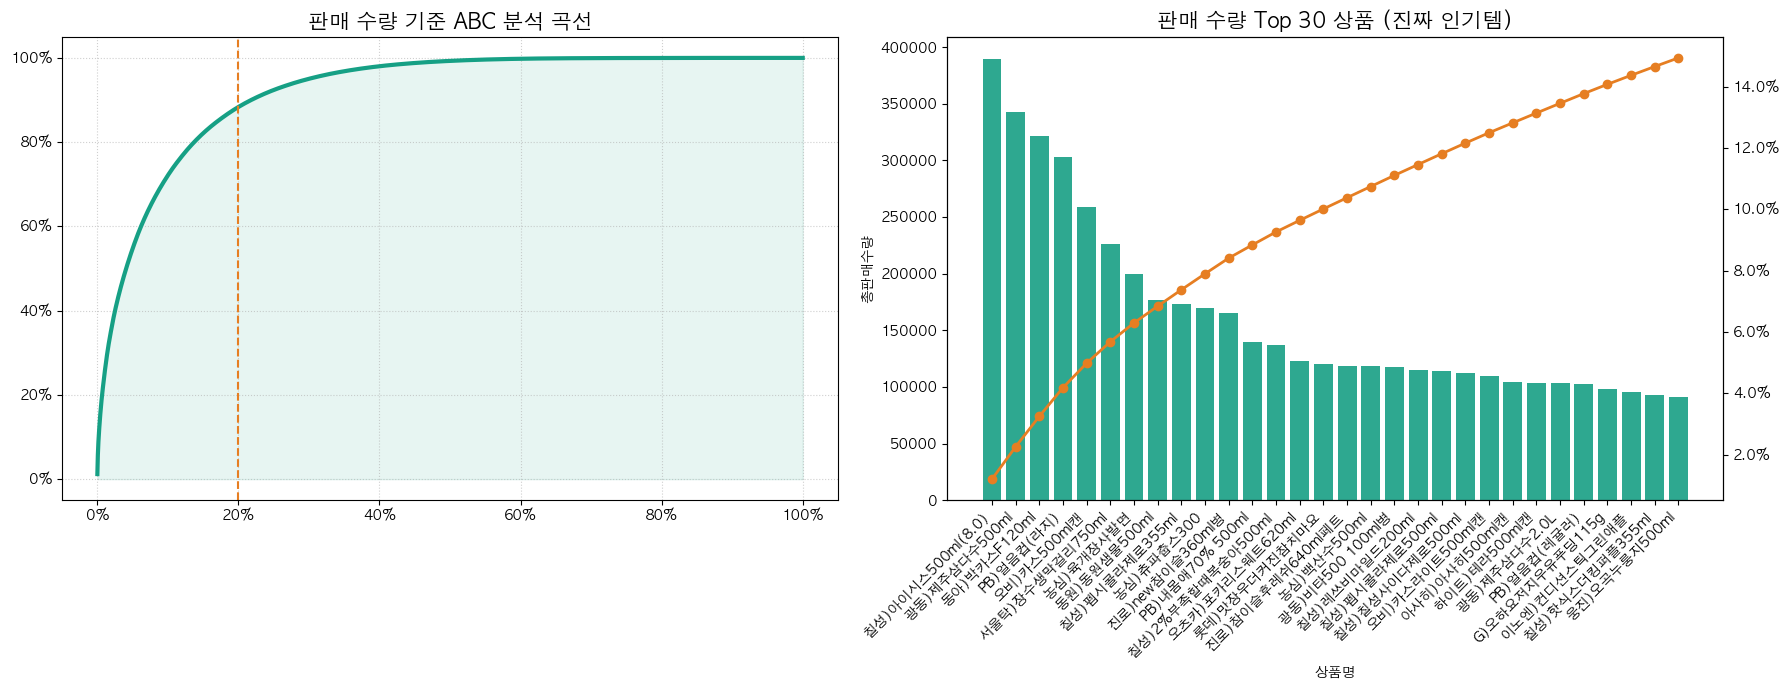

In [29]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

print("📦 상품별 '판매 수량' 기여도를 분석 중입니다...")

# 2. 상품별 총 판매수량 집계 및 정렬
product_qty_lazy = (
    df_lazy
    .group_by("상품명")
    .agg(pl.col("판매수량").sum().alias("총판매수량"))
    .sort("총판매수량", descending=True)
)

product_qty = product_qty_lazy.collect()

# 3. 누적 데이터 계산
total_qty = product_qty["총판매수량"].sum()
total_items = len(product_qty)

pareto_qty_df = (
    product_qty
    .with_columns([
        pl.col("총판매수량").cum_sum().alias("누적판매수량")
    ])
    .with_columns([
        (pl.col("누적판매수량") / total_qty * 100).alias("누적수량비중(%)"),
        (pl.Series(range(1, total_items + 1)) / total_items * 100).alias("상품누적비중(%)")
    ])
).to_pandas()

# 상위 20% 상품이 차지하는 수량 비중
top_20_qty_pct = pareto_qty_df[pareto_qty_df['상품누적비중(%)'] <= 20]['누적수량비중(%)'].max()

print(f"✅ 분석 완료! 전체 상품 수: {total_items:,}개")
print(f"🎯 수량 기준 상위 20% 상품이 전체 판매량의 {top_20_qty_pct:.1f}%를 차지합니다!")

# 4. 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 그래프 1: 수량 기준 로렌츠 곡선 ---
axes[0].plot(pareto_qty_df['상품누적비중(%)'], pareto_qty_df['누적수량비중(%)'], color='#16a085', linewidth=3)
axes[0].fill_between(pareto_qty_df['상품누적비중(%)'], pareto_qty_df['누적수량비중(%)'], alpha=0.1, color='#16a085')
axes[0].axvline(x=20, color='#e67e22', linestyle='--')
axes[0].set_title('판매 수량 기준 ABC 분석 곡선', fontsize=15)
axes[0].xaxis.set_major_formatter(PercentFormatter())
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- 그래프 2: 수량 기준 Top 30 파레토 차트 ---
top_30_qty = pareto_qty_df.head(30)
ax2 = axes[1]
ax3 = ax2.twinx()

sns.barplot(data=top_30_qty, x='상품명', y='총판매수량', color='#1abc9c', ax=ax2)
ax3.plot(top_30_qty.index, top_30_qty['누적수량비중(%)'], color='#e67e22', marker='o', linewidth=2)

ax2.set_title('판매 수량 Top 30 상품 (진짜 인기템)', fontsize=15)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax3.yaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()

[고가 상품 필터링 근거 및 방안 요약]

1. 데이터 왜곡 및 희소성 문제: 극소수의 고단가 상품은 전체 매출 지표를 크게 왜곡하며, 절대적인 판매 빈도가 부족해 연관 규칙의 최소 지지도(Support) 요건을 충족하지 못한다.

2. 분석 목적과의 불일치: 고가 주류 구매는 평균 객단가 1만 원 이하를 보인 대다수 고객의 일상적, 목적성 장바구니 동시 구매 패턴과 성격이 완전히 다르다.

3. 전처리 실행 방안: 본격적인 연관 지표(Support, Confidence, Lift) 산출 전, 상품 단가 "5만 원"을 초과하는 결제 건을 이상치로 규정하여 분석 데이터셋에서 제외한다.

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/1434273519.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='총판매수량', y='상품명', palette='viridis', **kwargs)
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/1434273519.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='총판매수량', y='상품명', palette='viridis', **kwargs)
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/1434273519.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='총판매수량', y='상품명', palette='

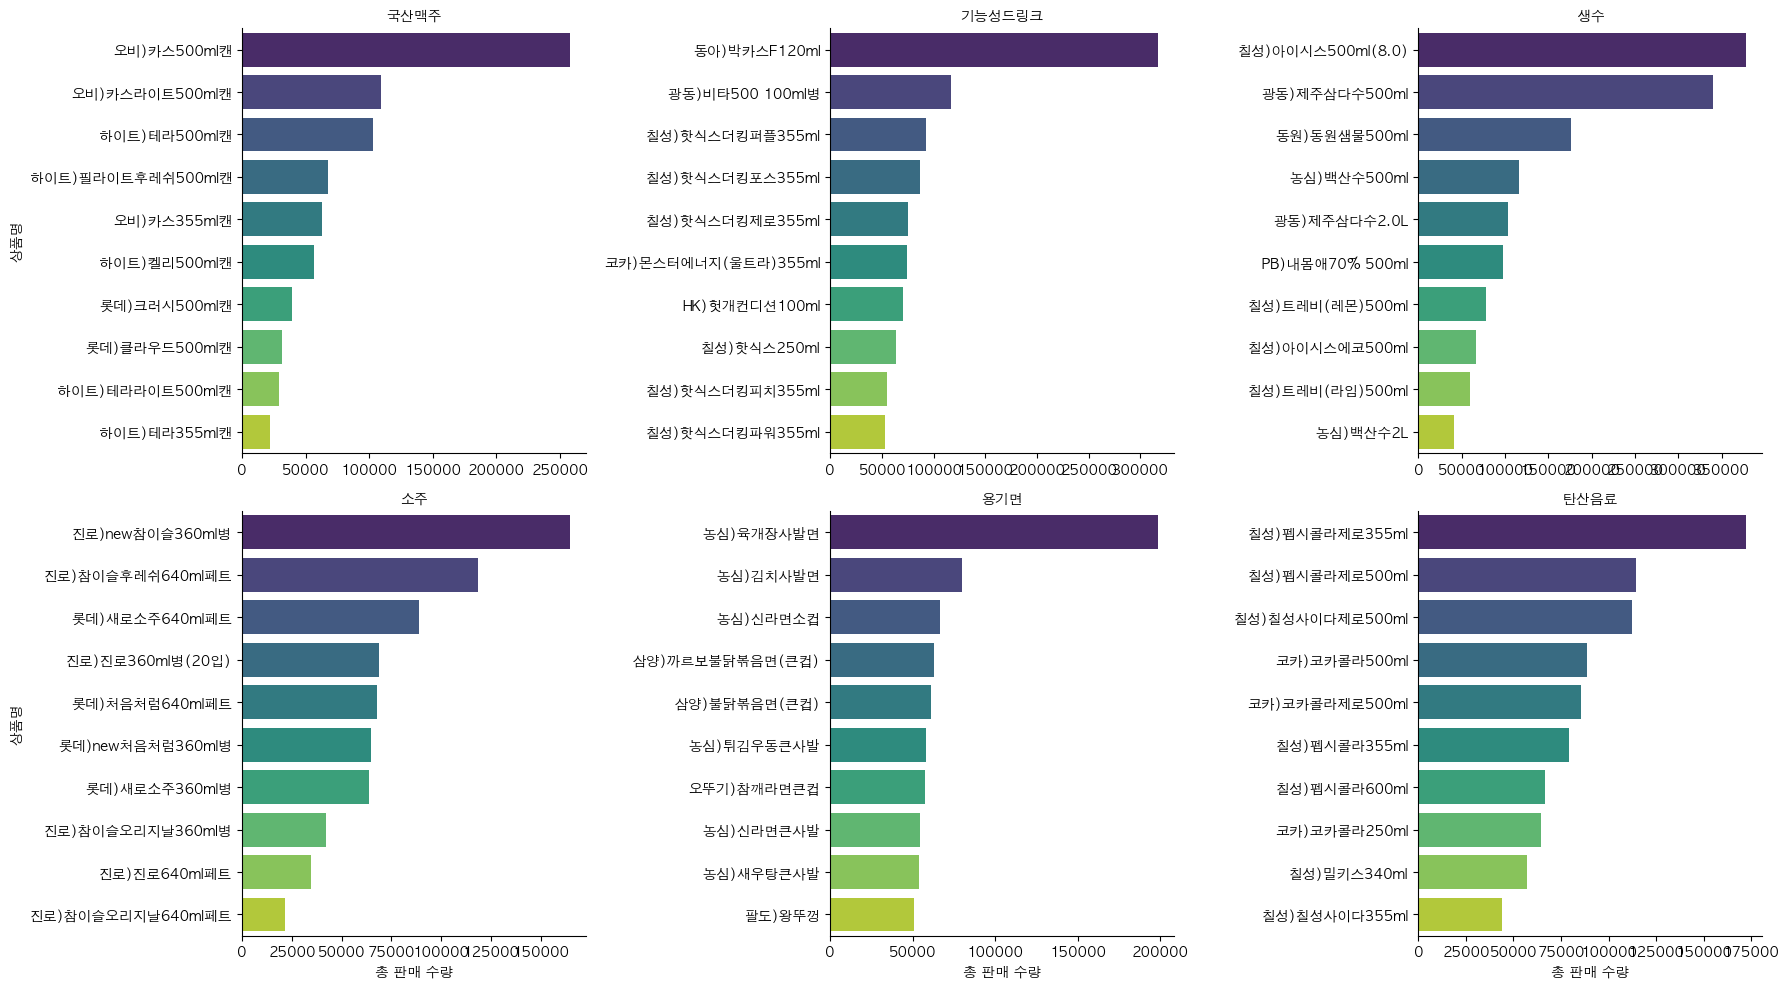

In [32]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 고가 상품 필터링 (5만 원 미만)
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

clean_df_lazy = df_lazy.filter(pl.col("판매금액") < 50000)

# 2. 중분류별 상품 판매 수량 집계
category_top_lazy = (
    clean_df_lazy
    .group_by(["중분류명", "상품명"])
    .agg(pl.col("판매수량").sum().alias("총판매수량"))
    .sort(["중분류명", "총판매수량"], descending=[False, True])
)

# 3. 중분류별 상위 10개 상품만 추출
# 그룹별로 순번을 매겨 상위 10개만 필터링
category_top_df = (
    category_top_lazy
    .with_columns(
        pl.col("총판매수량")
        .rank("dense", descending=True)
        .over("중분류명")
        .alias("rank")
    )
    .filter(pl.col("rank") <= 10)
    .collect()
    .to_pandas()
)

# 4. 주요 중분류 카테고리 선정 (시각화 가독성을 위해 상위 6개 카테고리만 출력)
main_categories = (
    category_top_df.groupby("중분류명")["총판매수량"].sum()
    .sort_values(ascending=False).head(6).index.tolist()
)

# 5. 시각화 (FacetGrid 활용)
g = sns.FacetGrid(
    category_top_df[category_top_df['중분류명'].isin(main_categories)], 
    col="중분류명", col_wrap=3, height=5, aspect=1.2, sharey=False, sharex=False
)

def draw_barplot(data, **kwargs):
    sns.barplot(data=data, x='총판매수량', y='상품명', palette='viridis', **kwargs)

g.map_dataframe(draw_barplot)
g.set_titles("{col_name}")
g.set_axis_labels("총 판매 수량", "상품명")

plt.tight_layout()
plt.show()

In [33]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 설정 및 경로
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
SAVE_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/TOTAL_CATEGORY_ANALYSIS.png'

# 2. 데이터 로드 및 전처리 (지윤이가 정한 5만원 필터링 적용!)
df_lazy = pl.scan_parquet(DATA_MART_PATH)

# 단가 5만원 미만 상품만 추출
clean_df_lazy = df_lazy.filter(pl.col("판매금액") < 50000)

print("📊 전체 중분류별 인기 상품 분석을 시작합니다...")

# 3. 중분류별 상품 판매 수량 집계
category_top_df = (
    clean_df_lazy
    .group_by(["중분류명", "상품명"])
    .agg(pl.col("판매수량").sum().alias("총판매수량"))
    # 중분류별로 랭킹 매기기 (오버 윈도우 함수 사용)
    .with_columns(
        pl.col("총판매수량")
        .rank("dense", descending=True)
        .over("중분류명")
        .alias("rank")
    )
    # 상위 10개만 필터링
    .filter(pl.col("rank") <= 10)
    .sort(["중분류명", "총판매수량"], descending=[False, True])
    .collect()
    .to_pandas()
)

# 4. 시각화 대상 카테고리 리스트업 (전체 다 보기!)
all_categories = category_top_df['중분류명'].unique().tolist()
num_cats = len(all_categories)
cols = 3  # 한 줄에 3개씩 배치
rows = (num_cats // cols) + (1 if num_cats % cols > 0 else 0)

print(f"✅ 총 {num_cats}개의 카테고리를 발견했습니다. 이미지 생성을 시작합니다.")

# 5. 시각화 (이미지 파일로 저장하기 위해 큰 도화지 준비)
# 카테고리가 많으므로 세로 길이를 넉넉하게 Rows * 5 정도로 잡음
fig = plt.figure(figsize=(18, rows * 5))

for i, cat in enumerate(all_categories):
    ax = fig.add_subplot(rows, cols, i + 1)
    plot_data = category_top_df[category_top_df['중분류명'] == cat]
    
    sns.barplot(
        data=plot_data, 
        x='총판매수량', 
        y='상품명', 
        palette='magma', 
        ax=ax
    )
    
    ax.set_title(f"[{cat}]", fontsize=15, fontweight='bold')
    ax.set_xlabel("판매 수량", fontsize=10)
    ax.set_ylabel("", fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

# 전체 레이아웃 조정
plt.tight_layout()

# 이미지 파일로 저장 (dpi를 높여서 확대해도 선명하게!)
plt.savefig(SAVE_PATH, dpi=150)
print(f"🎉 저장이 완료되었습니다! \n📁 경로: {SAVE_PATH}")

plt.close() # 메모리 관리를 위해 닫기

📊 전체 중분류별 인기 상품 분석을 시작합니다...
✅ 총 101개의 카테고리를 발견했습니다. 이미지 생성을 시작합니다.


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/2703604049.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/2703604049.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/2703604049.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/2703604049.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

🎉 저장이 완료되었습니다! 
📁 경로: /Users/hajiyoon/workspace/data/seveneleven_clean/TOTAL_CATEGORY_ANALYSIS.png


🎯 카테고리별 최적 가격대(Sweet Spot)를 분석 중입니다...


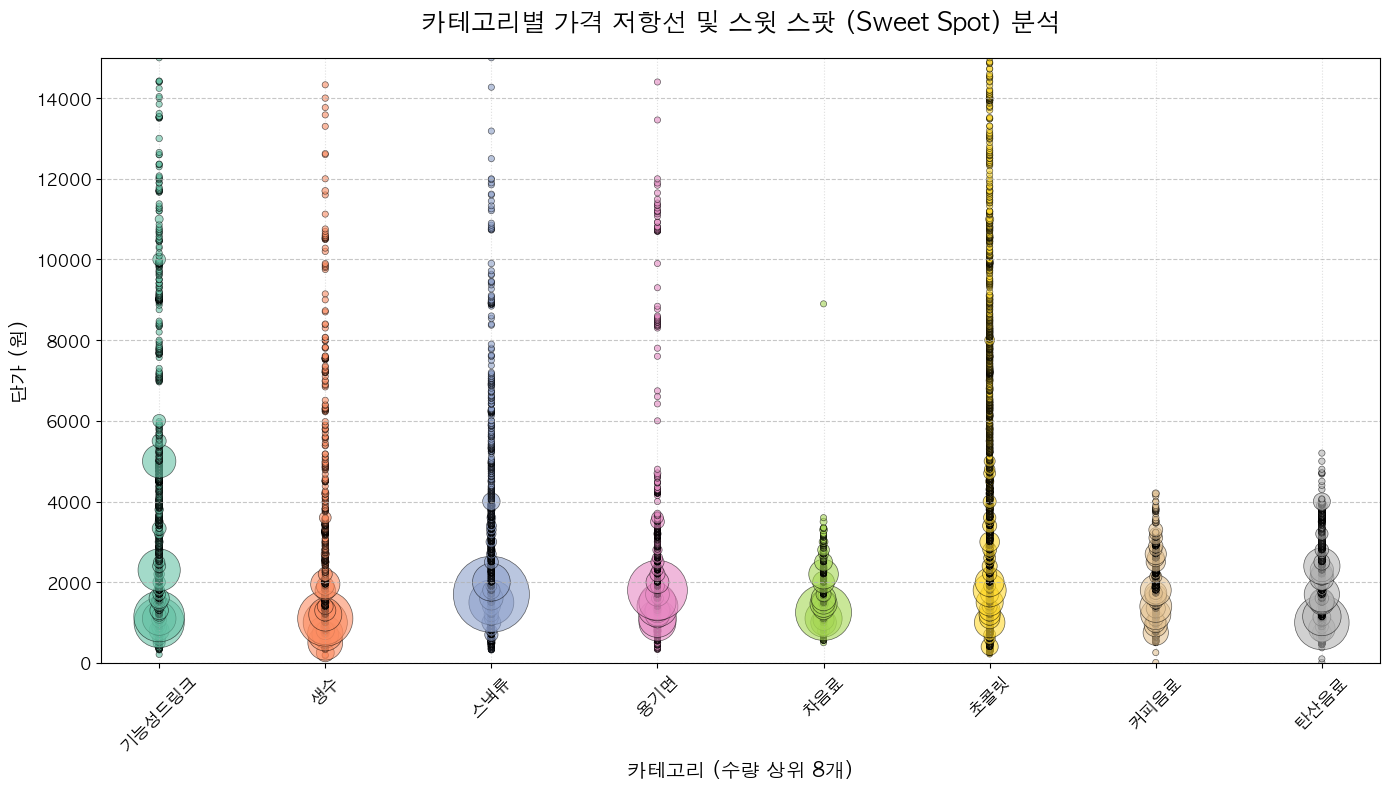

In [35]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

print("🎯 카테고리별 최적 가격대(Sweet Spot)를 분석 중입니다...")

# 2. 단가 계산 및 고가/저가 이상치 필터링
# 단가 = 판매금액 / 판매수량 (증정품 0원 및 5만원 이상 제외)
clean_df = (
    df_lazy
    .with_columns(
        (pl.col("판매금액") / pl.col("판매수량")).alias("단가")
    )
    .filter((pl.col("단가") > 0) & (pl.col("단가") < 50000))
)

# 3. 분석할 상위 핵심 카테고리 8개 자동 추출 (판매수량 기준)
top_categories = (
    clean_df
    .group_by("중분류명")
    .agg(pl.col("판매수량").sum().alias("총판매수량"))
    .sort("총판매수량", descending=True)
    .head(8)
    .select("중분류명")
    .collect()
    ["중분류명"].to_list()
)

# 4. 카테고리 & 단가별 총 판매수량 집계 (버블 차트용)
sweet_spot_data = (
    clean_df
    .filter(pl.col("중분류명").is_in(top_categories))
    .group_by(["중분류명", "단가"])
    .agg(pl.col("판매수량").sum().alias("수량"))
    .sort(["중분류명", "단가"])
    .collect()
    .to_pandas()
)

# 5. 시각화 (Bubble Chart)
plt.figure(figsize=(14, 8))

# seaborn scatterplot으로 수량에 따라 버블 크기(size)를 다르게 맵핑!
sns.scatterplot(
    data=sweet_spot_data,
    x='중분류명',
    y='단가',
    size='수량',
    sizes=(20, 3000),  # 버블 크기의 최소~최대 범위 (데이터에 맞게 조절 가능)
    hue='중분류명',
    palette='Set2',
    alpha=0.6,         # 버블이 겹쳐도 보이게 투명도 설정
    edgecolor='black',
    linewidth=0.5,
    legend=False       # 범례가 크기를 가리지 않게 숨김
)

# 💡 핵심: 편의점 매출의 격전지인 0원 ~ 15,000원 구간으로 돋보기 줌인!
plt.ylim(0, 15000) 

plt.title('카테고리별 가격 저항선 및 스윗 스팟 (Sweet Spot) 분석', fontsize=18, pad=20)
plt.xlabel('카테고리 (수량 상위 8개)', fontsize=14)
plt.ylabel('단가 (원)', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

# 가독성을 위한 그리드 추가 (단가 1000원 단위로 보기 쉽게)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

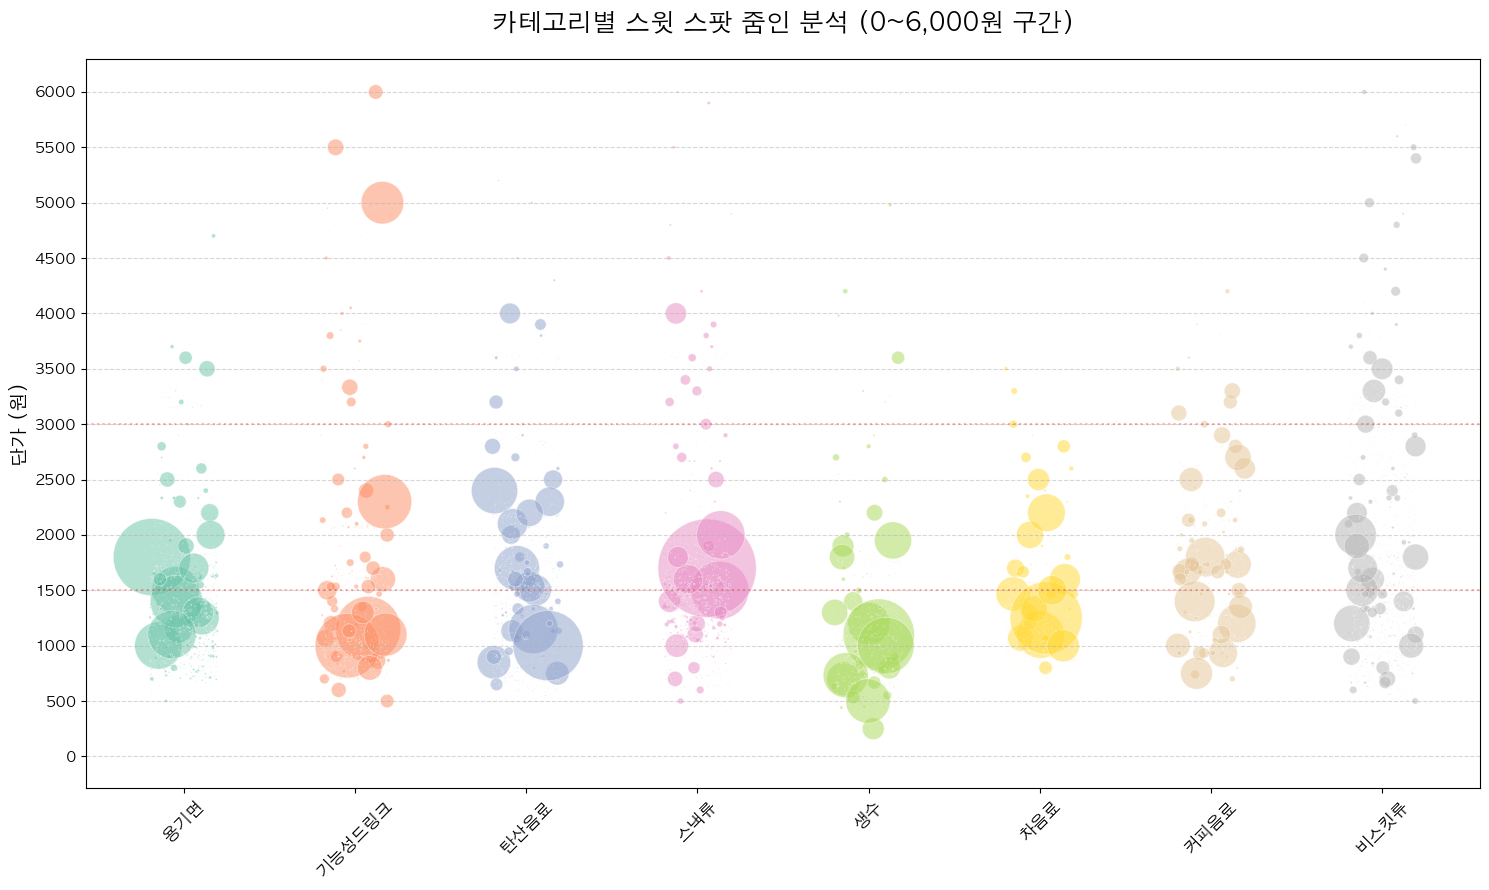

In [36]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 전처리
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

# 단가 계산 및 필터링 (0원 초과 ~ 6,000원 이하로 줌인!)
clean_df = (
    df_lazy
    .with_columns((pl.col("판매금액") / pl.col("판매수량")).alias("단가"))
    .filter((pl.col("단가") > 0) & (pl.col("단가") <= 6000))
)

# 2. 상위 8개 카테고리 추출 (지윤이가 본 그래프와 동일한 카테고리 유지)
top_categories = (
    clean_df.group_by("중분류명").agg(pl.col("판매수량").sum().alias("총판매수량"))
    .sort("총판매수량", descending=True).head(8).select("중분류명").collect()["중분류명"].to_list()
)

# 3. 데이터 집계
sweet_spot_data = (
    clean_df.filter(pl.col("중분류명").is_in(top_categories))
    .group_by(["중분류명", "단가"]).agg(pl.col("판매수량").sum().alias("수량"))
    .collect().to_pandas()
)

# 4. 시각화 (Jittering 적용)
plt.figure(figsize=(15, 9))

# x축 위치에 랜덤한 노이즈를 줘서 버블을 옆으로 펼침 (가독성 UP!)
category_map = {cat: i for i, cat in enumerate(top_categories)}
sweet_spot_data['x_jitter'] = sweet_spot_data['중분류명'].map(category_map) + np.random.uniform(-0.2, 0.2, size=len(sweet_spot_data))

# 버블 차트 그리기
scatter = plt.scatter(
    x=sweet_spot_data['x_jitter'],
    y=sweet_spot_data['단가'],
    s=sweet_spot_data['수량'] / sweet_spot_data['수량'].max() * 5000, # 버블 크기 스케일 조정
    c=sweet_spot_data['중분류명'].map(category_map),
    cmap='Set2',
    alpha=0.5,
    edgecolors='white',
    linewidth=0.5
)

# x축 설정
plt.xticks(range(len(top_categories)), top_categories, rotation=45, fontsize=12)
plt.yticks(range(0, 6500, 500), fontsize=11) # 500원 단위로 촘촘하게!

plt.title('카테고리별 스윗 스팟 줌인 분석 (0~6,000원 구간)', fontsize=18, pad=20)
plt.ylabel('단가 (원)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# 가로선 추가 (심리적 저항선 후보들)
plt.axhline(y=1500, color='red', linestyle=':', alpha=0.3, label='1,500원선')
plt.axhline(y=3000, color='red', linestyle=':', alpha=0.3, label='3,000원선')

plt.tight_layout()
plt.show()

💡 카테고리별 스윗 스팟 및 가격 저항선 분석 요약
1. 저단가 구간의 압도적 수요: 분석 대상인 8개 카테고리 모두 1,000원 ~ 2,500원 사이에서 가장 크고 밀집된 버블(스윗 스팟)이 형성되며, 편의점 식품 소비의 핵심 가격대임을 증명함.

2. 카테고리별 가격 저항선 확인: '용기면'과 '스낵류'는 3,000원, '생수'는 2,000원을 기점으로 버블 크기가 급격히 축소되며, 해당 가격대가 고객의 심리적 구매 마지노선으로 작용함.

3. 가격대별 수요 분포의 이질성: '기능성드링크'와 '비스킷류'는 5,000원 이상의 고단가 영역에서도 일정 규모의 버블이 유지되는 반면, '생수'와 '차음료'는 저단가에만 수요가 극단적으로 쏠리는 양극화 현상을 보임.

💡 핵심 분석 인사이트 (Insights)
1. 가성비 위주의 목적성 구매: 용기면(1,500원~2,000원)과 스낵류(1,700원)의 거대 버블은 고객들이 편의점에서 '끼니 해결'이나 '가벼운 간식'을 위해 가장 큰 비용 지불 용의가 있는 지점임.

2. 기능성/기호성 상품의 가격 탄력성: 기능성드링크와 비스킷류는 3,000~5,000원대에도 수요가 잔존하는바, 단순 가성비보다는 **'효능'이나 '브랜드/맛'**에 따라 가격 저항을 극복할 가능성이 높은 카테고리임.

3. 프로모션 전략 수립의 근거: 생수와 탄산음료의 버블이 1,000~1,500원대에 집중된 것으로 보아, 단품 인상보다는 **'1+1, 2+1 행사'**를 통해 실질 체감가를 스윗 스팟에 맞추는 전략이 판매량 유지에 필수적임.

데이터 한계 인지: 6개월 데이터는 '왼쪽 절단' 현상이 존재하며, 1월 판매 상품은 신제품 분석에서 제외하는 것이 타당하다.

신규성 정의: 1월 이후 첫 등장한 상품을 '신규 기획안'의 결과물로 간주하여 속성 조합을 추출한다.

지표 활용: 전체 수명보다는 초기 성장성과 6월 시점의 생존 여부를 '성공'의 라벨링 기준으로 삼는다.

In [38]:
# 1. 데이터 로드 및 기본 필터링 (이상치 제거)
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)
clean_df = df_lazy.filter(pl.col("판매금액") < 50000)

In [44]:
print(df_lazy.columns)

['판매일자', '판매시간', '점포코드', 'POS번호', '거래번호', '상품코드', '판매수량', '판매금액', '상품명', '대분류명', '중분류명', '소분류명']


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_71188/1956092707.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(df_lazy.columns)


📊 신상품 초기 주평균 판매량 통계치
                        0
평균             139.803648
중앙값(50%)         6.000000
상위25%_기준선(Q3)  118.500000
상위20%_기준선      173.500000
상위10%_기준선      393.750000


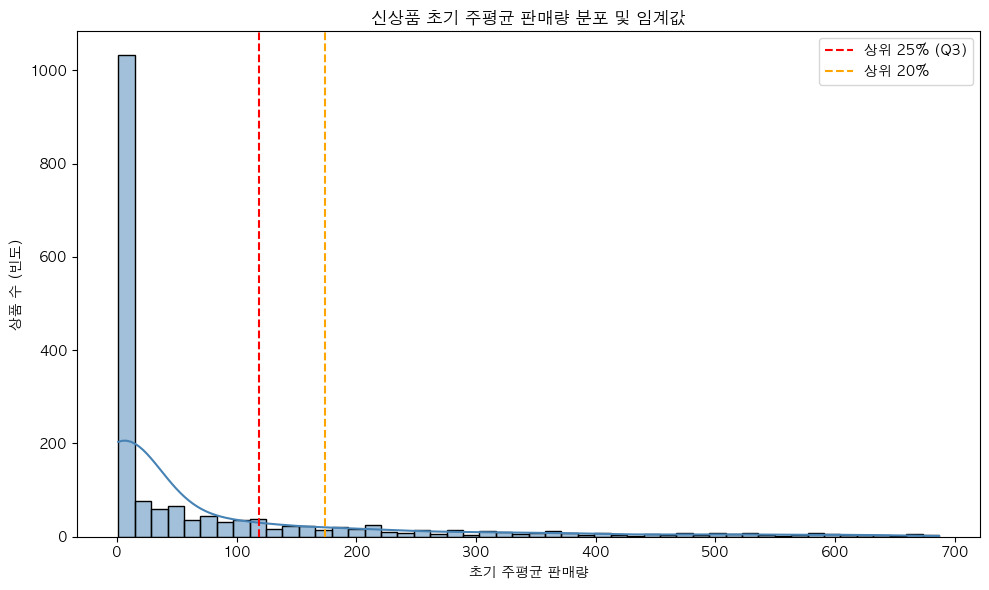

In [47]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# [Mac 한글 폰트 설정]
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 기술 통계량 및 백분위수 산출
sales_stats = success_labeling.select([
    pl.col("초기_주평균판매량").mean().alias("평균"),
    pl.col("초기_주평균판매량").median().alias("중앙값(50%)"),
    pl.col("초기_주평균판매량").quantile(0.75).alias("상위25%_기준선(Q3)"),
    pl.col("초기_주평균판매량").quantile(0.80).alias("상위20%_기준선"),
    pl.col("초기_주평균판매량").quantile(0.90).alias("상위10%_기준선")
]).to_pandas()

print("📊 신상품 초기 주평균 판매량 통계치")
print(sales_stats.T)

# 2. 데이터 분포 시각화 (변곡점 확인용)
plot_data = success_labeling.select("초기_주평균판매량").to_pandas()

plt.figure(figsize=(10, 6))
# 극단적인 이상치(초대박 상품)로 인한 그래프 찌그러짐 방지를 위해 x축 상한을 95백분위수로 제한
x_max = plot_data['초기_주평균판매량'].quantile(0.95)

sns.histplot(
    data=plot_data[plot_data['초기_주평균판매량'] <= x_max], 
    x='초기_주평균판매량', 
    bins=50, 
    kde=True,
    color='steelblue'
)

plt.axvline(x=sales_stats['상위25%_기준선(Q3)'].values[0], color='red', linestyle='--', label='상위 25% (Q3)')
plt.axvline(x=sales_stats['상위20%_기준선'].values[0], color='orange', linestyle='--', label='상위 20%')

plt.title('신상품 초기 주평균 판매량 분포 및 임계값')
plt.xlabel('초기 주평균 판매량')
plt.ylabel('상품 수 (빈도)')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
import polars as pl
from datetime import date
import pandas as pd

# 1. 데이터 로드 및 전처리
DATA_MART_PATH = '/Users/hajiyoon/workspace/data/seveneleven_clean/B2_CLEAN_FOOD_BASKET.parquet'
df_lazy = pl.scan_parquet(DATA_MART_PATH)

# 컬럼명 반영: '판매금액'으로 이상치 제거
df_lazy = df_lazy.filter((pl.col("판매금액") / pl.col("판매수량")) < 50000)
print("🚀 분석을 시작합니다...")

# 2. 상품별 최초/최근 판매일 추출 (기존/신규 구분용)
# '판매일자' 컬럼이 문자열(ex: '20250101')이라면 .str.to_date("%Y%m%d") 처리가 필요할 수 있어!
clean_df = clean_df.with_columns(pl.col("판매일자").str.to_date("%Y%m%d"))
product_stats = (
    clean_df
    .group_by("상품명")
    .agg([
        pl.col("판매일자").min().alias("최초판매일"),
        pl.col("판매일자").max().alias("최근판매일")
    ])
    .with_columns(
        pl.when(pl.col("최초판매일") <= date(2025, 1, 31))
        .then(pl.lit("기존상품"))
        .otherwise(pl.lit("신규상품"))
        .alias("상품구분")
    )
)

# 3. 신규 상품만 추출
new_products = product_stats.filter(pl.col("상품구분") == "신규상품")

# 4. 초기 4주 트렌드 집계
new_sales_trend = (
    clean_df
    .join(new_products, on="상품명")
    .with_columns(
        # 판매일자 - 최초판매일 계산 (경과 주차)
        ((pl.col("판매일자") - pl.col("최초판매일")).dt.total_days() // 7).alias("경과주차")
    )
    .filter(pl.col("경과주차") < 4)
    .group_by(["상품명", "경과주차", "최근판매일"])
    .agg(pl.col("판매수량").sum().alias("주간판매수량"))
)

# 5. 최종 성공 라벨링
success_labeling = (
    new_sales_trend
    .group_by(["상품명", "최근판매일"])
    .agg([
        pl.col("주간판매수량").mean().alias("초기_주평균판매량"),
        pl.col("주간판매수량").count().alias("초기_판매발생주차수")
    ])
    .with_columns(
        pl.when(
            (pl.col("초기_주평균판매량") >= 119) & 
            (pl.col("초기_판매발생주차수") >= 3) & 
            (pl.col("최근판매일") >= date(2025, 6, 1))
        )
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .alias("성공여부")
    )
).collect()

print("✅ 분석 완료!")
print(f"전체 신상품 수: {len(success_labeling)}")
print(f"성공 판정 상품 수 (성공여부=1): {success_labeling['성공여부'].sum()}")
print(success_labeling.head())

🚀 분석을 시작합니다...
✅ 분석 완료!
전체 신상품 수: 1864
성공 판정 상품 수 (성공여부=1): 412
shape: (5, 5)
┌────────────────────────────────┬────────────┬───────────────────┬─────────────────────┬──────────┐
│ 상품명                         ┆ 최근판매일 ┆ 초기_주평균판매량 ┆ 초기_판매발생주차수 ┆ 성공여부 │
│ ---                            ┆ ---        ┆ ---               ┆ ---                 ┆ ---      │
│ str                            ┆ date       ┆ f64               ┆ u32                 ┆ i32      │
╞════════════════════════════════╪════════════╪═══════════════════╪═════════════════════╪══════════╡
│ 미스티)마이초코23g             ┆ 2025-06-30 ┆ 167.0             ┆ 4                   ┆ 1        │
│ 고운벗)꽃새우쌀과자100g        ┆ 2025-06-30 ┆ 59.25             ┆ 4                   ┆ 0        │
│ 롯데)마주앙모젤750ml           ┆ 2025-06-16 ┆ 3.0               ┆ 1                   ┆ 0        │
│ M_현)비비고설렁탕500g          ┆ 2025-05-12 ┆ 1.0               ┆ 1                   ┆ 0        │
│ 레뱅드)버블넘버원핑크라벨750ml ┆ 2025-04-12 ┆ 1.0               ┆ 1               

초기 주평균 판매량 (볼륨): 비대칭적 판매량 분포(우측 꼬리가 긴 형태)에서 발생하는 평균의 오류를 배제하기 위해, 전체 데이터의 상위 25% 지점인 제3사분위수(Q3, 주평균 119개)를 초기 시장 안착을 판단하는 통계적 임계값으로 채택함.

초기 판매 발생 주차수 (연속성): 초도 발주 물량이나 일시적 유행에 의한 데이터 왜곡을 통제하고자, 출시 초기 4주 중 3주 이상의 연속적 판매 발생

최근 판매일 (생존 지속성): 6개월 차(6월)까지의 생존 여부를 지속성 검증 조건으로 결합함. (2025년 6월 1일 이후에도 판매된 기록이 있어야 한다.)

단가 5만 원 미만의 일상 소비재 중 위 세 가지 기준을 모두 충족한 상품을 추출한 결과, 전체 1,864개 중 상위 22.1%에 해당하는 412개 상품만이 파레토 법칙에 부합하는 핵심 성공 자산으로 분류됨.

In [52]:
# 1. 성공 상품 데이터와 중분류 카테고리 결합
# (성공여부=1인 412개 상품의 카테고리 비중 확인)
success_items_only = success_labeling.filter(pl.col("성공여부") == 1)

# 2. 중분류별 성공 상품 개수 집계
category_stats = (
    clean_df
    .select(["상품명", "중분류명"])
    .unique() # 상품명과 중분류명 1:1 매핑 정보 추출
    .join(success_items_only.lazy(), on="상품명")
    .group_by("중분류명")
    .agg(pl.col("상품명").count().alias("성공상품수"))
    .sort("성공상품수", descending=True)
).collect()

print("🏆 상반기 신제품 성공 상품 배출 Top 10 카테고리")
print(category_stats.head(10))

🏆 상반기 신제품 성공 상품 배출 Top 10 카테고리
shape: (10, 2)
┌──────────────┬────────────┐
│ 중분류명     ┆ 성공상품수 │
│ ---          ┆ ---        │
│ str          ┆ u32        │
╞══════════════╪════════════╡
│ 노벨티       ┆ 33         │
│ 스낵류       ┆ 31         │
│ 간식빵       ┆ 29         │
│ 젤리류       ┆ 26         │
│ 비스킷류     ┆ 25         │
│ 캔디류       ┆ 20         │
│ 냉장간식     ┆ 16         │
│ 용기면       ┆ 15         │
│ 기능성드링크 ┆ 14         │
│ 도시락       ┆ 13         │
└──────────────┴────────────┘
